# Structural Backfire Analysis

For each run, we:
1. Identify all targeted nodes from the step-20000 GEXF (`target=True`)
2. **Filter seeds where targeting executed**: seeds where no run has a `target=True` node in `step_20000.gexf` are excluded (these are runs where the moderate-influencer pool was empty at step 20000, causing an early stop). Mirrors `build_valid_seeds()` in `result-summary.ipynb`.
3. Characterise targeted nodes' structural position by averaging across all targets: in-degree, betweenness centrality, local clustering coefficient, PageRank, eigenvector centrality
4. Measure the backfire effect: Δopposite − Δtarget post-share (late window minus pre-intervention baseline)
5. Scatter-plot each structural metric against backfire magnitude with Spearman correlation

The `n_targets` column records how many targets were active per run.

**Note on eigenvector centrality:** computed as the left eigenvector of the directed adjacency matrix (hub score). Falls back to NaN if power iteration fails to converge.

In [35]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import xml.etree.ElementTree as ET
from scipy import stats

RESULTS_DIR = "./results"
BINS = ["bin_0", "bin_1", "bin_2", "bin_3", "bin_4"]

# step window just before intervention = baseline; end of simulation = outcome
PRE_RANGE  = (19000, 20000)
POST_RANGE = (39000, 40000)


def _gexf_has_target(fpath):
    """Return True if any node in the GEXF has target=True."""
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag:
                elem.tag = elem.tag.split('}', 1)[1]
        attr_map = {}
        for attr in root.findall(".//attributes[@class='node']/attribute"):
            attr_map[attr.get('id')] = attr.get('title')
        for node in root.findall(".//node"):
            for av in node.findall(".//attvalue"):
                title = attr_map.get(av.get('for'), av.get('for'))
                if title == 'target' and av.get('value', '').lower() == 'true':
                    return True
    except Exception:
        pass
    return False


def build_valid_seeds(results_dir, check_step=20000):
    """
    Exclude seeds where no run has a target=True node in step_{check_step}.gexf.
    Mirrors the exclusion logic in result-summary.ipynb.
    """
    seed_dirs = glob.glob(os.path.join(results_dir, "run_*_dir_*"))
    seeds_found = set()
    for d in seed_dirs:
        m = re.match(r'run_(\d+)_dir_', os.path.basename(d))
        if m:
            seeds_found.add(int(m.group(1)))

    valid, excluded = [], []
    for seed in sorted(seeds_found):
        gexf_files = glob.glob(
            os.path.join(results_dir, f"run_{seed}_dir_*", "GEXF", "*", f"step_{check_step}.gexf")
        )
        if any(_gexf_has_target(f) for f in gexf_files):
            valid.append(seed)
        else:
            excluded.append(seed)

    print(f"Seeds with target nodes   : {valid}")
    print(f"Seeds excluded (no target): {excluded}")
    return valid


SEEDS = build_valid_seeds(RESULTS_DIR)

Seeds with target nodes   : [1, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15, 16, 17, 19, 20, 22, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 36, 37, 39, 41, 42, 43, 44, 45, 46, 47, 48, 50, 52, 53, 54, 55, 57, 58, 60, 61, 63, 64, 66, 67, 69, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 83, 86, 87, 89, 91, 95]
Seeds excluded (no target): [0, 2, 3, 8, 13, 18, 21, 23, 25, 35, 38, 40, 49, 51, 56, 59, 62, 65, 68, 70, 79, 84, 85, 88, 90, 92, 93, 94, 96, 97, 98, 99]


In [36]:
# ---------------------------------------------------------------------------
# GEXF parsing: return (DiGraph, list_of_target_node_ids, node_opinions)
# node_opinions: dict {node_id: float opinion at this snapshot}
# ---------------------------------------------------------------------------
def parse_gexf_for_target(fpath):
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag:
                elem.tag = elem.tag.split('}', 1)[1]

        attr_map = {}
        for attr in root.findall(".//attributes[@class='node']/attribute"):
            attr_map[attr.get('id')] = attr.get('title')

        G = nx.DiGraph()
        target_nodes = []
        node_opinions = {}

        for node in root.findall(".//node"):
            nid = node.get('id')
            G.add_node(nid)
            for av in node.findall(".//attvalue"):
                title = attr_map.get(av.get('for'), av.get('for'))
                if title == 'target' and av.get('value', '').lower() == 'true':
                    target_nodes.append(nid)
                if title == 'opinion':
                    try:
                        node_opinions[nid] = float(av.get('value'))
                    except (TypeError, ValueError):
                        pass

        for edge in root.findall(".//edge"):
            G.add_edge(edge.get('source'), edge.get('target'))

        return G, target_nodes, node_opinions
    except Exception as e:
        print(f"  [WARN] GEXF parse failed ({fpath}): {e}")
        return None, [], {}


def _compute_modularity(G):
    """
    Directed modularity Q (Leicht & Newman 2008) with Louvain partition.

    Community detection runs on the undirected projection of G — necessary
    because Louvain is defined for undirected graphs. The partition is then
    scored on the original directed graph using the directed null model:

        Q = (1/m) * Σ_{ij} [A_{ij} − k_i^{out} * k_j^{in} / m] * δ(c_i, c_j)

    where m = total directed edges, k^{out}/k^{in} are out/in-degree.
    This is the correct null model for follower networks: the probability of
    a directed edge i→j under the configuration model scales as
    k_i^{out} * k_j^{in} / m, not with total degree.

    Louvain (Blondel et al. 2008) is preferred; falls back to
    greedy_modularity_communities (Clauset, Newman & Moore 2004) otherwise.

    Q in [-0.5, 1]: ~0 = no community structure; ≥0.3 = meaningful modularity.
    Returns nan if graph is too small or detection fails.
    """
    if G is None or len(G.nodes) < 4:
        return np.nan
    try:
        G_und = G.to_undirected()
        try:
            communities = nx.community.louvain_communities(G_und, seed=42)
        except AttributeError:
            communities = list(nx.community.greedy_modularity_communities(G_und))
        # Evaluate Q on the original directed graph (Leicht-Newman directed formula)
        return nx.community.modularity(G, communities)
    except Exception:
        return np.nan


def get_target_structural_metrics(G, target_id):
    """Node-level structural indices for the targeted agent."""
    if G is None or target_id is None or target_id not in G:
        return {}

    in_degree = G.in_degree(target_id)

    bc_all = nx.betweenness_centrality(G, normalized=True)
    betweenness = bc_all.get(target_id, np.nan)

    # Fagiolo (2007) directed local clustering coefficient
    clustering = nx.clustering(G, target_id)

    pr_all = nx.pagerank(G, alpha=0.85, max_iter=200)
    pagerank = pr_all.get(target_id, np.nan)

    try:
        ec_all = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)
        eigenvector = ec_all.get(target_id, np.nan)
    except nx.PowerIterationFailedConvergence:
        eigenvector = np.nan

    return {
        'in_degree':   in_degree,
        'betweenness': betweenness,
        'clustering':  clustering,
        'pagerank':    pagerank,
        'eigenvector': eigenvector,
    }


def get_follower_opinion_metrics(G, target_id, node_opinions, target_sign):
    """
    Opinion-based homophily metrics for the target's follower (in-neighbor) set.

    follower_mean_opinion   : signed mean opinion of followers
    follower_opinion_std    : std of follower opinions (echo-chamber depth)
    follower_homophily_frac : fraction of followers with same sign as the **target** (E-I index analogue)
    follower_dir_alignment  : fraction of followers aligned with the **manipulation direction**
                              (sign matches target_sign) — key predictor for backfire
    target_opinion          : target node's own opinion at the snapshot
    """
    if G is None or target_id is None or target_id not in G:
        return {}

    target_op = node_opinions.get(target_id, np.nan)

    # in-neighbors are the nodes whose edges point TO the target (i.e. followers)
    followers = list(G.predecessors(target_id))
    follower_ops = np.array([node_opinions[f] for f in followers if f in node_opinions])

    if len(follower_ops) == 0:
        return {
            'target_opinion':          target_op,
            'follower_mean_opinion':   np.nan,
            'follower_opinion_std':    np.nan,
            'follower_homophily_frac': np.nan,
            'follower_dir_alignment':  np.nan,
        }

    same_sign_as_target = np.sign(follower_ops) == np.sign(target_op) if not np.isnan(target_op) else np.nan
    same_sign_as_dir    = np.sign(follower_ops) == np.sign(target_sign)

    return {
        'target_opinion':          target_op,
        'follower_mean_opinion':   float(np.mean(follower_ops)),
        'follower_opinion_std':    float(np.std(follower_ops)),
        'follower_homophily_frac': float(np.mean(same_sign_as_target)) if not np.isnan(target_op) else np.nan,
        'follower_dir_alignment':  float(np.mean(same_sign_as_dir)),
    }


def average_metrics(metric_list):
    """Average a list of metric dicts across targets, ignoring NaN per key."""
    if not metric_list:
        return {}
    keys = metric_list[0].keys()
    result = {}
    for k in keys:
        vals = [m[k] for m in metric_list
                if k in m and not (isinstance(m[k], float) and np.isnan(m[k]))]
        result[k] = float(np.mean(vals)) if vals else np.nan
    return result

In [37]:
# ---------------------------------------------------------------------------
# Backfire effect per run
# backfire_effect = (Δopposite_share) − (Δtarget_share)
# Positive value  => opposite side grew more = backfire
# ---------------------------------------------------------------------------
def compute_backfire_effect(run_dir, target_sign, pre_range, post_range):
    post_dir = os.path.join(run_dir, "posts")
    files = glob.glob(os.path.join(post_dir, "post_result_*.csv"))
    if not files:
        return np.nan

    dfs = []
    for f in files:
        try:
            dfs.append(pd.read_csv(f))
        except Exception:
            pass
    if not dfs:
        return np.nan

    df = pd.concat(dfs, ignore_index=True).sort_values('step')

    # relative bin assignment
    if target_sign > 0:
        target_bins   = ["bin_3", "bin_4"]
        opposite_bins = ["bin_0", "bin_1"]
    else:
        target_bins   = ["bin_0", "bin_1"]
        opposite_bins = ["bin_3", "bin_4"]

    def mean_share(df, bins, step_range):
        mask = (df['step'] >= step_range[0]) & (df['step'] <= step_range[1])
        sub = df[mask].copy()
        if sub.empty:
            return np.nan
        total = sub[BINS].sum(axis=1).replace(0, np.nan)
        return (sub[bins].sum(axis=1) / total).mean()

    target_pre    = mean_share(df, target_bins,   pre_range)
    target_post   = mean_share(df, target_bins,   post_range)
    opposite_pre  = mean_share(df, opposite_bins, pre_range)
    opposite_post = mean_share(df, opposite_bins, post_range)

    delta_target   = target_post   - target_pre
    delta_opposite = opposite_post - opposite_pre

    return delta_opposite - delta_target

In [38]:
# ---------------------------------------------------------------------------
# Main data collection loop
# ---------------------------------------------------------------------------
records = []
run_dirs = sorted(glob.glob(os.path.join(RESULTS_DIR, "run_*")))
print(f"Found {len(run_dirs)} run directories.")

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m:
        continue
    seed        = int(m.group(1))
    target_sign = float(m.group(2))

    if SEEDS is not None and seed not in SEEDS:
        continue

    gexf_files = glob.glob(os.path.join(run_dir, "GEXF", "*", "step_20000.gexf"))
    if not gexf_files:
        print(f"  [SKIP] {dirname}: no step_20000 GEXF")
        continue

    print(f"Processing {dirname} ...", end=" ")
    G, target_ids, node_opinions = parse_gexf_for_target(gexf_files[0])
    if not target_ids:
        print("no target nodes (pool was empty, run excluded)")
        continue

    # Compute per-target metrics then average across targets (characterises the intervention)
    struct_list    = [get_target_structural_metrics(G, tid) for tid in target_ids]
    homophily_list = [get_follower_opinion_metrics(G, tid, node_opinions, target_sign) for tid in target_ids]
    struct    = average_metrics(struct_list)
    homophily = average_metrics(homophily_list)

    # Global network modularity Q (graph-level, not per-node)
    graph_modularity = _compute_modularity(G)

    backfire = compute_backfire_effect(run_dir, target_sign, PRE_RANGE, POST_RANGE)

    records.append({
        'run_id':          dirname,
        'seed':            seed,
        'target_sign':     target_sign,
        'target_id':       ';'.join(target_ids),
        'n_targets':       len(target_ids),
        'backfire_effect': backfire,
        'modularity':      graph_modularity,
        **struct,
        **homophily,
    })
    print(f"targets={target_ids}, n={len(target_ids)}, "
          f"dir_align={homophily.get('follower_dir_alignment', float('nan')):.3f}, "
          f"homophily={homophily.get('follower_homophily_frac', float('nan')):.3f}, "
          f"modularity={graph_modularity:.4f}, "
          f"backfire={backfire:.4f}")

df = pd.DataFrame(records)
print(f"\nCollected {len(df)} valid runs.")
print(df[['seed', 'target_sign', 'n_targets', 'in_degree', 'betweenness', 'clustering',
          'pagerank', 'eigenvector', 'modularity',
          'target_opinion', 'follower_mean_opinion', 'follower_opinion_std',
          'follower_homophily_frac', 'follower_dir_alignment',
          'backfire_effect']].describe())

Found 200 run directories.
Processing run_10_dir_-1.0 ... targets=['2'], n=1, dir_align=0.455, homophily=0.545, modularity=0.3695, backfire=-0.0192
Processing run_10_dir_1.0 ... targets=['2'], n=1, dir_align=0.545, homophily=0.545, modularity=0.3695, backfire=0.1318
Processing run_11_dir_-1.0 ... targets=['2'], n=1, dir_align=0.578, homophily=0.578, modularity=0.4544, backfire=0.0923
Processing run_11_dir_1.0 ... targets=['2'], n=1, dir_align=0.422, homophily=0.578, modularity=0.4544, backfire=-0.0079
Processing run_12_dir_-1.0 ... targets=['5'], n=1, dir_align=0.769, homophily=0.769, modularity=0.4721, backfire=0.0152
Processing run_12_dir_1.0 ... targets=['5'], n=1, dir_align=0.231, homophily=0.769, modularity=0.4721, backfire=0.0415
Processing run_14_dir_-1.0 ... targets=['1'], n=1, dir_align=0.362, homophily=0.638, modularity=0.3953, backfire=0.0222
Processing run_14_dir_1.0 ... targets=['1'], n=1, dir_align=0.638, homophily=0.638, modularity=0.3953, backfire=0.1054
Processing run_

In [39]:
# ---------------------------------------------------------------------------
# Seed-level collapse: signed mean backfire_effect across both directions.
#
# mean_backfire = (backfire_neg + backfire_pos) / 2
#
# Cancellation is intentional: if dir=−1 gives +0.06 and dir=+1 gives −0.06
# (the typical mirror case), the seed-level mean is ~0, correctly indicating
# no net backfire tendency. A positive mean_backfire means backfire dominates
# regardless of direction; a negative mean means manipulation consistently works.
# ---------------------------------------------------------------------------
from collections import defaultdict

_by_seed = defaultdict(dict)
for _, row in df.iterrows():
    _by_seed[int(row['seed'])][row['target_sign']] = row

seed_records = []
for seed in sorted(_by_seed.keys()):
    d = _by_seed[seed]
    if -1.0 not in d or 1.0 not in d:
        continue  # require both direction runs
    base = d[-1.0].to_dict()
    base['backfire_neg']        = d[-1.0]['backfire_effect']
    base['backfire_pos']        = d[1.0]['backfire_effect']
    base['mean_backfire']       = (d[-1.0]['backfire_effect'] + d[1.0]['backfire_effect']) / 2
    base['follower_alignment_pos'] = d[1.0]['follower_dir_alignment']
    seed_records.append(base)

df_seed = pd.DataFrame(seed_records).reset_index(drop=True)
print(f"Seed-level frame: {len(df_seed)} seeds")
print(df_seed[['seed', 'in_degree', 'betweenness', 'clustering',
               'pagerank', 'eigenvector', 'modularity', 'mean_backfire']].describe())

Seed-level frame: 68 seeds
            seed   in_degree  betweenness  clustering   pagerank  eigenvector  \
count  68.000000   68.000000    68.000000   68.000000  68.000000    68.000000   
mean   46.308824  312.323529     0.000219    0.013522   0.052167     0.102380   
std    26.353655  212.992638     0.000229    0.009294   0.076249     0.206590   
min     1.000000  103.000000     0.000000    0.003110   0.003936     0.000002   
25%    25.500000  129.750000     0.000051    0.006501   0.006427     0.000021   
50%    45.500000  199.500000     0.000138    0.010303   0.010932     0.000071   
75%    69.500000  575.500000     0.000291    0.018509   0.083895     0.000318   
max    95.000000  693.000000     0.001027    0.036747   0.316022     0.647984   

       modularity  mean_backfire  
count   68.000000      67.000000  
mean     0.403663       0.025328  
std      0.056203       0.026253  
min      0.293466      -0.006185  
25%      0.366200       0.006881  
50%      0.399929       0.015883 

---
## Section 1: All-Seeds Analysis

The analyses in this section pool all 70 valid seeds across both manipulation directions. They characterise how the structural position and opinion environment of the targeted node predict backfire magnitude, averaged over all seeds and both intervention directions. No split by backfire class is applied here.

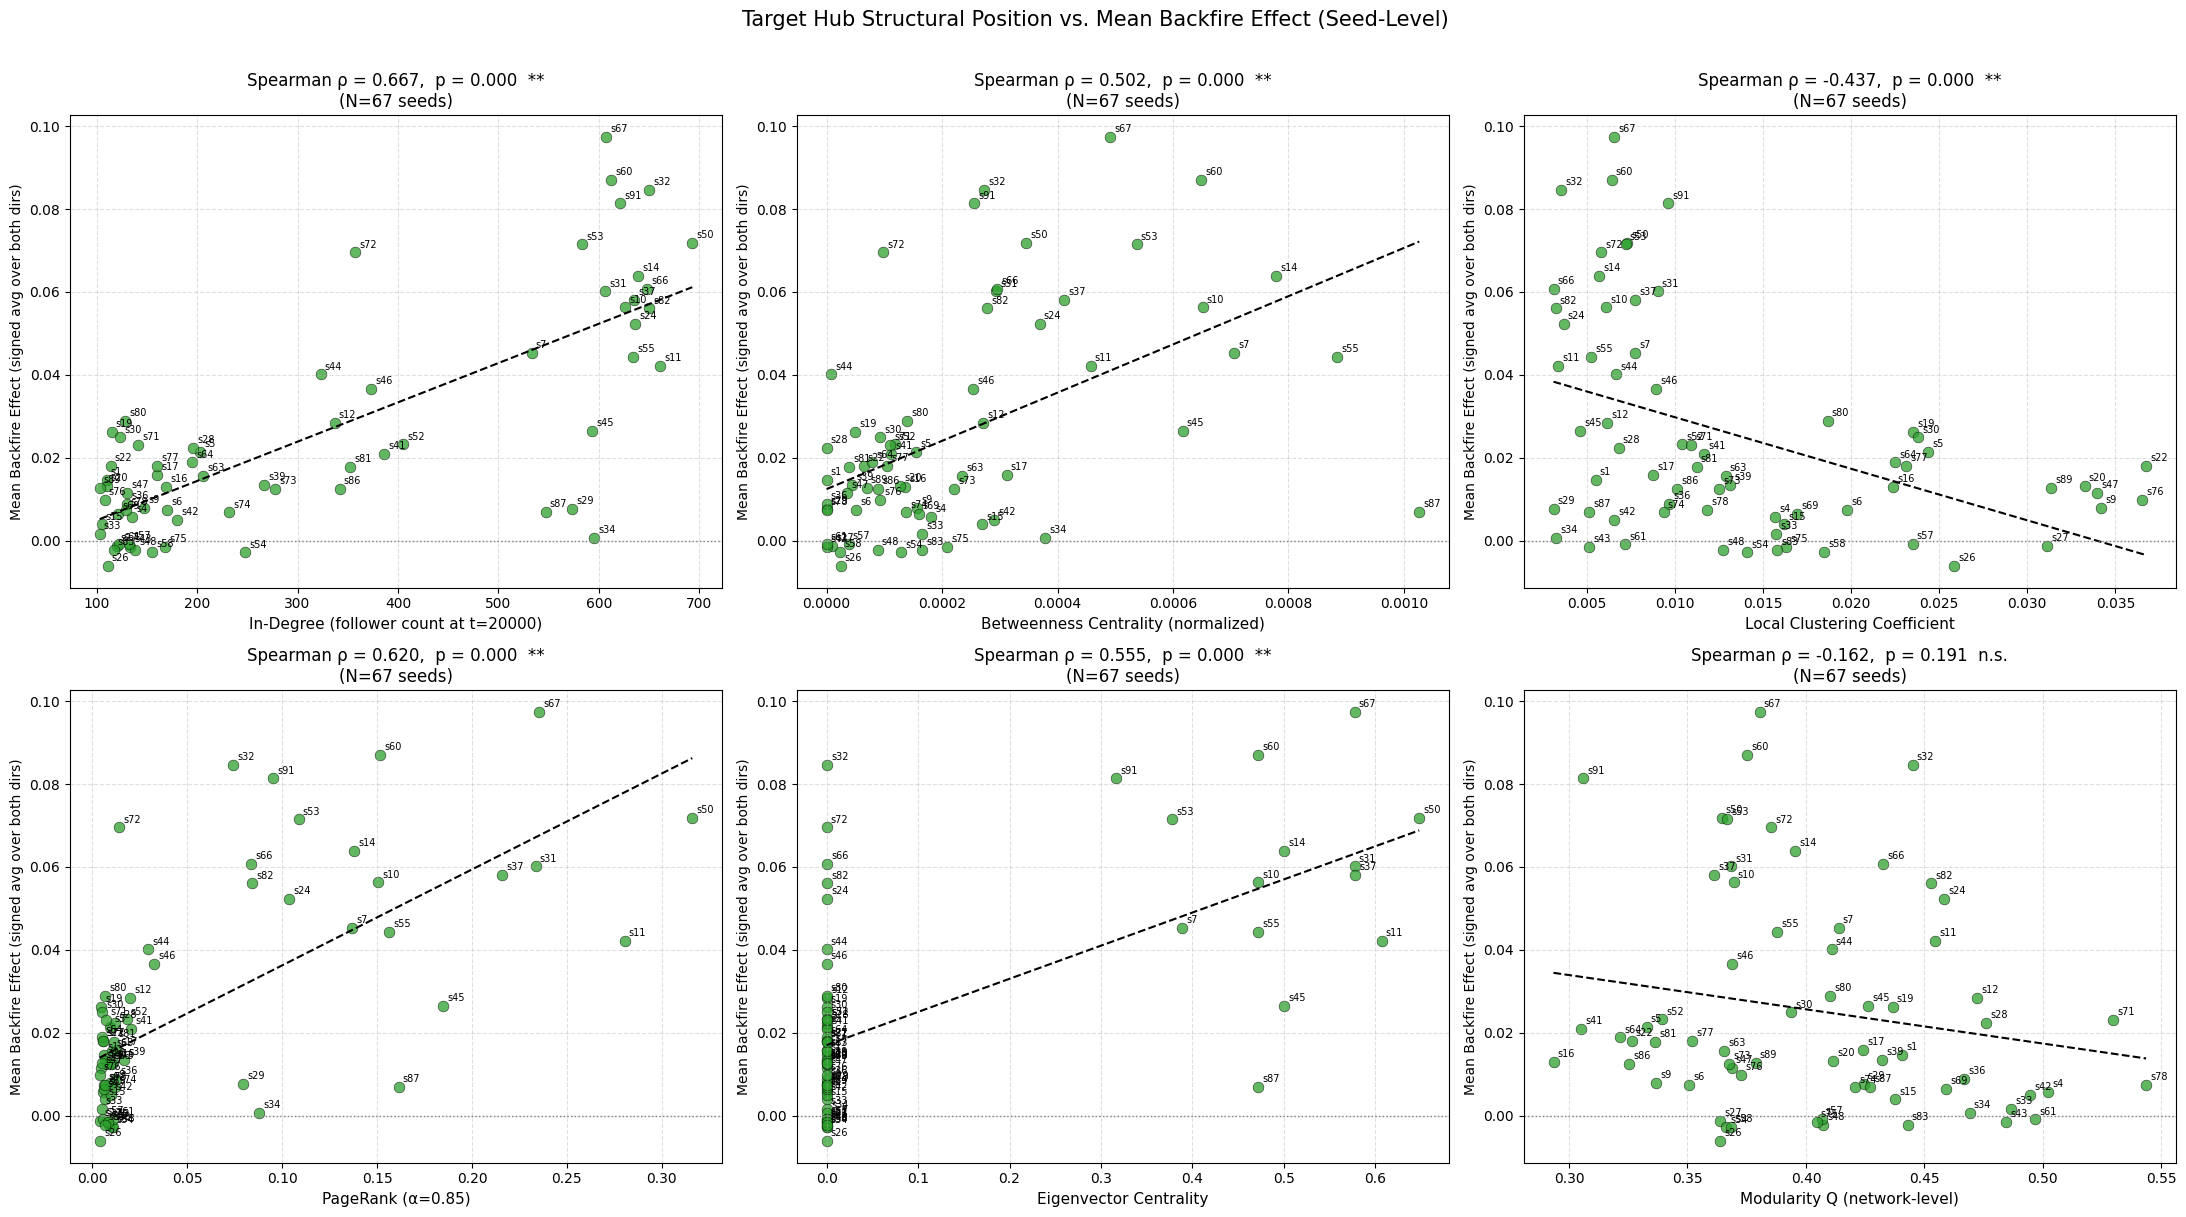

Figure saved to results/summary/structural_backfire_seedlevel.png


In [40]:
# ---------------------------------------------------------------------------
# Scatter plots: structural metric (x) vs mean signed backfire (y)
# Y-axis = (backfire_neg + backfire_pos) / 2 — cancellation permitted.
# ---------------------------------------------------------------------------
STRUCTURAL_METRICS = [
    ('in_degree',   'In-Degree (follower count at t=20000)'),
    ('betweenness', 'Betweenness Centrality (normalized)'),
    ('clustering',  'Local Clustering Coefficient'),
    ('pagerank',    'PageRank (α=0.85)'),
    ('eigenvector', 'Eigenvector Centrality'),
    ('modularity',  'Modularity Q (network-level)'),
]

df_plot = df_seed.dropna(subset=['mean_backfire'])

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for ax, (metric, xlabel) in zip(axes, STRUCTURAL_METRICS):
    sub = df_plot.dropna(subset=[metric])
    if sub.empty:
        ax.set_title(f"{metric}\n(no data)")
        continue

    x = sub[metric].values
    y = sub['mean_backfire'].values

    ax.scatter(x, y, color='#2ca02c', alpha=0.75, s=60, edgecolors='k', linewidths=0.4)

    for _, row in sub.iterrows():
        ax.annotate(f"s{int(row['seed'])}", (row[metric], row['mean_backfire']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 2), textcoords='offset points')

    slope, intercept, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)

    rho, p = stats.spearmanr(x, y)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Mean Backfire Effect (signed avg over both dirs)', fontsize=10)
    ax.set_title(f'Spearman ρ = {rho:.3f},  p = {p:.3f}  {sig}\n(N={len(sub)} seeds)', fontsize=12)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Target Hub Structural Position vs. Mean Backfire Effect (Seed-Level)', fontsize=15, y=1.01)
plt.tight_layout()

os.makedirs(os.path.join(RESULTS_DIR, "summary"), exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, "summary", "structural_backfire_seedlevel.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/summary/structural_backfire_seedlevel.png")

## Follower Opinion Homophily vs Backfire

Four metrics capturing the opinion composition of the target's follower (in-neighbor) set at t=20,000:

| Metric | Interpretation |
|---|---|
| `follower_mean_opinion` | signed mean — positive = followers lean right; captures network bias around target |
| `follower_opinion_std` | spread — low = echo chamber; high = ideologically diverse following |
| `follower_homophily_frac` | fraction of followers with same sign as the **target** (E-I index analogue) |
| `follower_dir_alignment` | fraction of followers aligned with the **manipulation direction** — key predictor: high alignment means many followers who *oppose* the intervention will mobilize |

`follower_dir_alignment` is the theoretically central measure: it operationalises the counter-mobilisation mechanism directly.

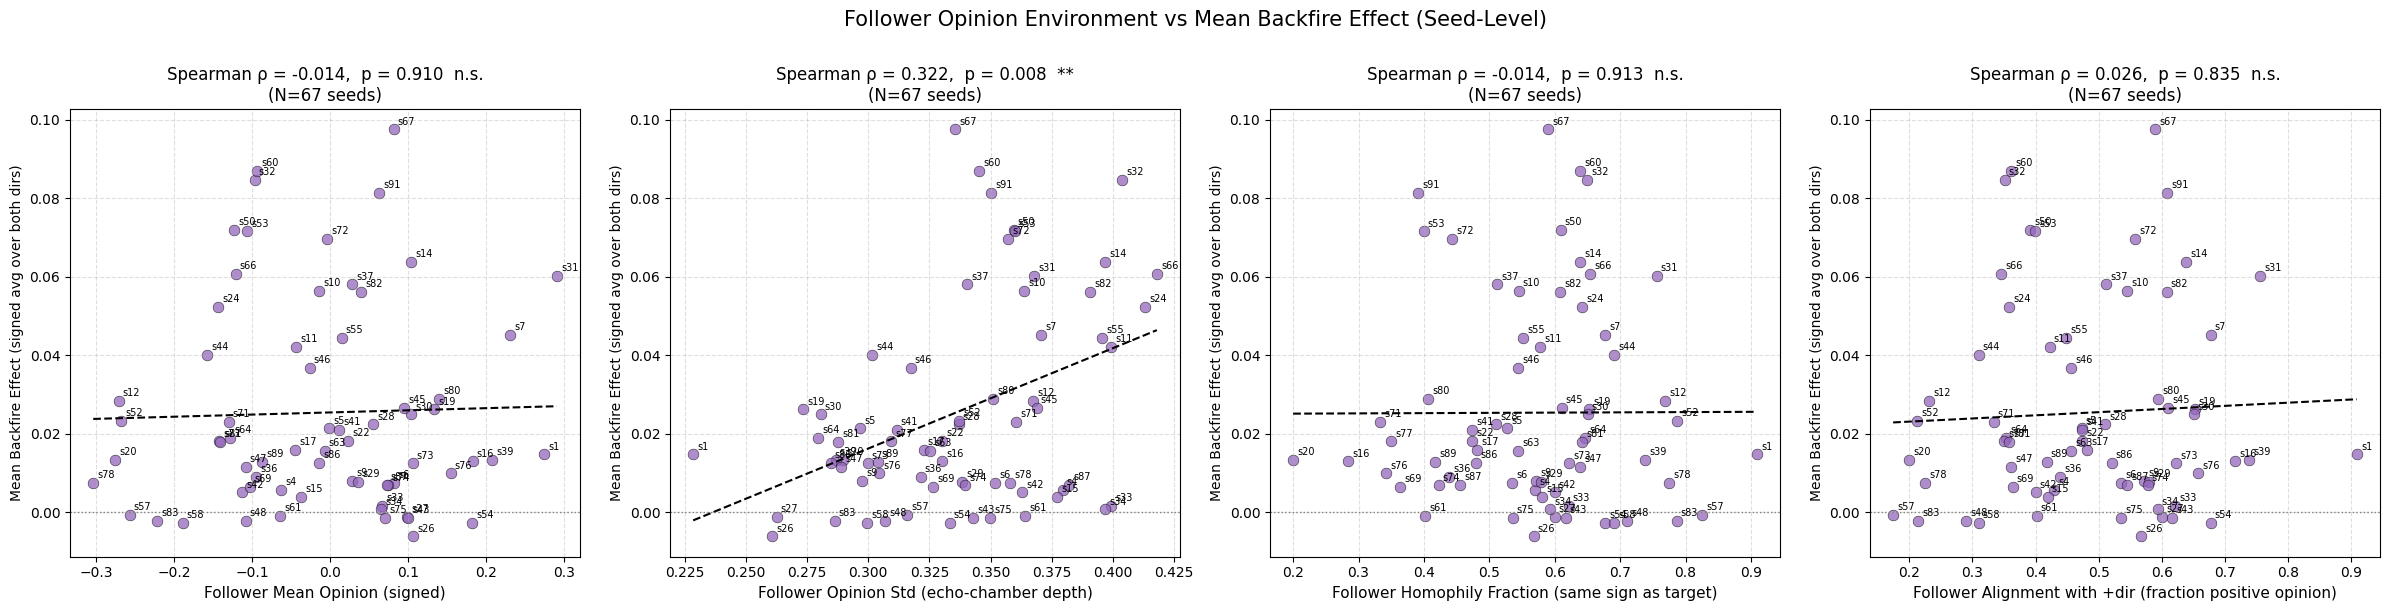

Figure saved to results/summary/homophily_backfire_seedlevel.png

follower_dir_alignment ~ backfire_effect: per-direction Spearman (run-level)
  dir=-1  N=67  rho=+0.174  p=0.1595  n.s.
  dir=+1  N=67  rho=+0.220  p=0.0741  n.s.


In [41]:
# ---------------------------------------------------------------------------
# Homophily metrics vs mean signed backfire (seed-level).
# ---------------------------------------------------------------------------
HOMOPHILY_METRICS_INVARIANT = [
    ('follower_mean_opinion',   'Follower Mean Opinion (signed)'),
    ('follower_opinion_std',    'Follower Opinion Std (echo-chamber depth)'),
    ('follower_homophily_frac', 'Follower Homophily Fraction (same sign as target)'),
    ('follower_alignment_pos',  'Follower Alignment with +dir (fraction positive opinion)'),
]

df_plot = df_seed.dropna(subset=['mean_backfire'])

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (metric, xlabel) in zip(axes, HOMOPHILY_METRICS_INVARIANT):
    sub = df_plot.dropna(subset=[metric])
    if sub.empty:
        ax.set_title(f"{metric}\n(no data)")
        continue

    x = sub[metric].values
    y = sub['mean_backfire'].values

    ax.scatter(x, y, color='#9467bd', alpha=0.75, s=60, edgecolors='k', linewidths=0.4)

    for _, row in sub.iterrows():
        ax.annotate(f"s{int(row['seed'])}", (row[metric], row['mean_backfire']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 2), textcoords='offset points')

    slope, intercept, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)

    rho, p = stats.spearmanr(x, y)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Mean Backfire Effect (signed avg over both dirs)', fontsize=10)
    ax.set_title(f'Spearman ρ = {rho:.3f},  p = {p:.3f}  {sig}\n(N={len(sub)} seeds)', fontsize=12)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Follower Opinion Environment vs Mean Backfire Effect (Seed-Level)", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "homophily_backfire_seedlevel.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/summary/homophily_backfire_seedlevel.png")

# ---------- per-direction Spearman for follower_dir_alignment ----------
# Direction-specific metric: tested per direction on raw run-level df.
print("\nfollower_dir_alignment ~ backfire_effect: per-direction Spearman (run-level)")
df_run_plot = df.dropna(subset=['backfire_effect'])
for sign in [-1.0, 1.0]:
    sub = df_run_plot[df_run_plot['target_sign'] == sign].dropna(subset=['follower_dir_alignment'])
    rho, p = stats.spearmanr(sub['follower_dir_alignment'], sub['backfire_effect'])
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    print(f"  dir={sign:+.0f}  N={len(sub)}  rho={rho:+.3f}  p={p:.4f}  {sig}")

### Section 1 — Additional Analyses: Target Follower Dynamics Around Intervention

Three complementary analyses tracking how the target's follower environment changes around step 20 000 (the intervention point). All use **direction-relative group labels** — opinion bins are mapped relative to the manipulation direction, never hard-coded:

| Label | Meaning | dir = +1 bin | dir = −1 bin |
|---|---|---|---|
| `far_opposite` | Furthest from target direction | 0 | 4 |
| `near_opposite` | Close to opposite side | 1 | 3 |
| `neutral` | Centre | 2 | 2 |
| `near_target` | Close to target direction | 3 | 1 |
| `far_target` | Furthest toward target direction | 4 | 0 |

| # | What is measured | Comparison |
|---|---|---|
| 1 | Follower opinion composition | step 20 000 (pre) vs step 40 000 (post) |
| 2 | Net unfollowing count by class | window 0→20 000 vs 20 000→40 000 |
| 3 | Posting share by class (from post CSV) | steps 19 000–20 000 vs 39 000–40 000 |

Analysis 1: collecting follower opinion distributions ...


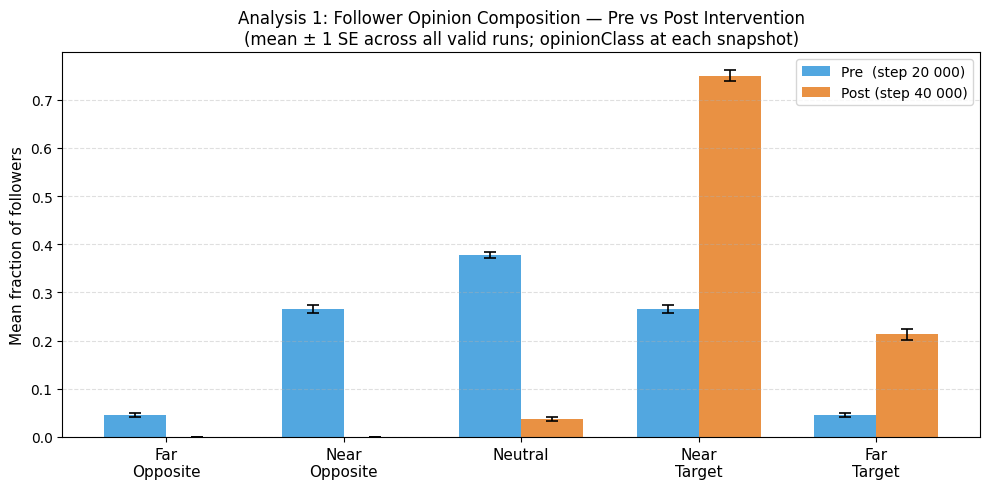

Saved: results/summary/follower_opinion_dist_change.png

Mean ± SE of follower fraction by group and window:

  pre:
    far_opposite      mean=0.0455  SE=0.0041
    near_opposite     mean=0.2659  SE=0.0087
    neutral           mean=0.3772  SE=0.0057
    near_target       mean=0.2659  SE=0.0087
    far_target        mean=0.0455  SE=0.0041

  post:
    far_opposite      mean=0.0000  SE=0.0000
    near_opposite     mean=0.0000  SE=0.0000
    neutral           mean=0.0370  SE=0.0048
    near_target       mean=0.7497  SE=0.0111
    far_target        mean=0.2133  SE=0.0114


In [42]:
# =========================================================================
# Direction-relative group constants (used by all three new analyses below;
# also re-defined in Section 2 cells — values are identical).
# =========================================================================
_POS_MAP = {
     1.0: {0: 'far_opposite', 1: 'near_opposite', 2: 'neutral', 3: 'near_target', 4: 'far_target'},
    -1.0: {0: 'far_target',   1: 'near_target',   2: 'neutral', 3: 'near_opposite', 4: 'far_opposite'},
}
GROUP_ORDER  = ['far_opposite', 'near_opposite', 'neutral', 'near_target', 'far_target']
GROUP_LABELS = ['Far\nOpposite', 'Near\nOpposite', 'Neutral', 'Near\nTarget', 'Far\nTarget']


def _parse_gexf_full(fpath):
    """One-pass GEXF parse -> (DiGraph, target_ids, {nid: {opinionclass, postprob}})."""
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag:
                elem.tag = elem.tag.split('}', 1)[1]
        attr_map = {}
        for attr in root.findall(".//attributes[@class='node']/attribute"):
            attr_map[attr.get('id')] = attr.get('title')
        G = nx.DiGraph()
        target_ids, agents = [], {}
        for node in root.findall(".//node"):
            nid = node.get('id')
            G.add_node(nid)
            d = {'opinionclass': -1, 'postprob': np.nan}
            for av in node.findall(".//attvalue"):
                t = attr_map.get(av.get('for'), av.get('for'))
                v = av.get('value', '')
                if t == 'opinionClass':
                    try: d['opinionclass'] = int(v)
                    except: pass
                elif t == 'postProb':
                    try: d['postprob'] = float(v)
                    except: pass
                elif t == 'target' and v.lower() == 'true':
                    target_ids.append(nid)
            agents[nid] = d
        for edge in root.findall(".//edge"):
            G.add_edge(edge.get('source'), edge.get('target'))
        return G, target_ids, agents
    except Exception:
        return None, [], {}


def _gexf_path(run_dir, step):
    fs = glob.glob(os.path.join(run_dir, 'GEXF', '*', f'step_{step}.gexf'))
    return fs[0] if fs else None


# ---------------------------------------------------------------------------
# Analysis 1: Follower opinion composition — step 20 000 vs step 40 000
# opinionClass is read from each respective snapshot so the plot shows the
# actual opinion distribution of whoever is following the target at that time.
# ---------------------------------------------------------------------------
fol_dist_records = []
print('Analysis 1: collecting follower opinion distributions ...')

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m: continue
    seed, target_sign = int(m.group(1)), float(m.group(2))
    if seed not in set(SEEDS): continue

    fp_20k = _gexf_path(run_dir, 20000)
    if not fp_20k: continue
    G_20k, target_ids, agents_20k = _parse_gexf_full(fp_20k)
    if not target_ids or G_20k is None: continue
    tid = target_ids[0]

    for window, G_cur, agents_cur in [('pre', G_20k, agents_20k), ('post', None, None)]:
        if window == 'post':
            fp = _gexf_path(run_dir, 40000)
            if not fp: continue
            G_cur, _, agents_cur = _parse_gexf_full(fp)
            if G_cur is None or tid not in G_cur: continue

        followers = list(G_cur.predecessors(tid)) if tid in G_cur else []
        counts = {g: 0 for g in GROUP_ORDER}
        total = 0
        for f in followers:
            oc = agents_cur.get(f, {}).get('opinionclass', -1)
            if oc not in range(5): continue
            grp = _POS_MAP[target_sign].get(oc, 'unknown')
            if grp in counts:
                counts[grp] += 1
                total += 1
        for grp in GROUP_ORDER:
            fol_dist_records.append({
                'seed': seed, 'target_sign': target_sign, 'window': window,
                'relative_group': grp,
                'fraction': counts[grp] / total if total > 0 else np.nan,
            })

df_fol_dist = pd.DataFrame(fol_dist_records)
_gb_fd = df_fol_dist.groupby(['window', 'relative_group'])['fraction']
pivot_fd    = _gb_fd.mean().unstack('relative_group')[GROUP_ORDER]
pivot_fd_se = _gb_fd.sem() .unstack('relative_group')[GROUP_ORDER]

_ekw = dict(elinewidth=1.2, ecolor='k', capthick=1.2)
x = np.arange(len(GROUP_ORDER))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, pivot_fd.loc['pre'].values,  w,
       yerr=pivot_fd_se.loc['pre'].values,  capsize=4, error_kw=_ekw,
       label='Pre  (step 20 000)', color='#3498db', alpha=0.85)
ax.bar(x + w/2, pivot_fd.loc['post'].values, w,
       yerr=pivot_fd_se.loc['post'].values, capsize=4, error_kw=_ekw,
       label='Post (step 40 000)', color='#e67e22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, fontsize=11)
ax.set_ylabel('Mean fraction of followers', fontsize=11)
ax.set_title(
    'Analysis 1: Follower Opinion Composition — Pre vs Post Intervention\n'
    '(mean \u00b1 1 SE across all valid runs; opinionClass at each snapshot)',
    fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'summary', 'follower_opinion_dist_change.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: results/summary/follower_opinion_dist_change.png')
print('\nMean \u00b1 SE of follower fraction by group and window:')
for win in ['pre', 'post']:
    print(f'\n  {win}:')
    for grp in GROUP_ORDER:
        print(f'    {grp:16s}  mean={pivot_fd.loc[win, grp]:.4f}  SE={pivot_fd_se.loc[win, grp]:.4f}')


In [43]:
def parse_gexf_agent_attrs(fpath):
    """Parse one GEXF snapshot. Returns {node_id: {opinion, postprob, opinionclass, is_target}}."""
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag:
                elem.tag = elem.tag.split('}', 1)[1]

        attr_map = {}
        for attr in root.findall(".//attributes[@class='node']/attribute"):
            attr_map[attr.get('id')] = attr.get('title')

        agents = {}
        for node in root.findall(".//node"):
            nid = node.get('id')
            d = {'opinion': np.nan, 'postprob': np.nan, 'opinionclass': np.nan, 'is_target': False}
            for av in node.findall(".//attvalue"):
                title = attr_map.get(av.get('for'), av.get('for'))
                val   = av.get('value', '')
                if title == 'opinion':
                    try: d['opinion'] = float(val)
                    except ValueError: pass
                elif title == 'postProb':
                    try: d['postprob'] = float(val)
                    except ValueError: pass
                elif title == 'opinionClass':
                    try: d['opinionclass'] = int(val)
                    except ValueError: pass
                elif title == 'target':
                    d['is_target'] = (val.lower() == 'true')
            agents[nid] = d
        return agents
    except Exception:
        return {}


def compute_run_agent_deltas(run_dir, pre_steps, post_steps,
                              class_ref_step=15000, target_ref_step=20000):
    """
    Per-agent Δopinion and Δpostprob across the manipulation boundary.

    opinionClass is read from class_ref_step (= step 15000, last pre-manipulation snapshot).
    is_target flag is read from target_ref_step (= step 20000, when the flag is first set).
    Returns list of dicts, one per non-target agent. Empty list on parse failure.
    """
    gexf_base = os.path.join(run_dir, "GEXF")

    def _load(step):
        fs = glob.glob(os.path.join(gexf_base, "*", f"step_{step}.gexf"))
        return parse_gexf_agent_attrs(fs[0]) if fs else {}

    ref_class  = _load(class_ref_step)   # opinionclass (pre-manipulation)
    ref_target = _load(target_ref_step)  # is_target flag (set at manipulation start)
    if not ref_class:
        return []

    pre_snaps  = [d for s in pre_steps  for d in [_load(s)] if d]
    post_snaps = [d for s in post_steps for d in [_load(s)] if d]
    if not pre_snaps or not post_snaps:
        return []

    rows = []
    for nid, ref_c in ref_class.items():
        if ref_target.get(nid, {}).get('is_target', False):
            continue

        p_ops = [sn[nid]['opinion']  for sn in pre_snaps  if nid in sn and not np.isnan(sn[nid]['opinion'])]
        p_pps = [sn[nid]['postprob'] for sn in pre_snaps  if nid in sn and not np.isnan(sn[nid]['postprob'])]
        q_ops = [sn[nid]['opinion']  for sn in post_snaps if nid in sn and not np.isnan(sn[nid]['opinion'])]
        q_pps = [sn[nid]['postprob'] for sn in post_snaps if nid in sn and not np.isnan(sn[nid]['postprob'])]

        if not p_ops or not p_pps or not q_ops or not q_pps:
            continue

        oc = ref_c['opinionclass']
        rows.append({
            'node_id':        nid,
            'opinionclass':   int(oc) if not np.isnan(oc) else -1,
            'pre_opinion':    float(np.mean(p_ops)),
            'post_opinion':   float(np.mean(q_ops)),
            'delta_opinion':  float(np.mean(q_ops) - np.mean(p_ops)),
            'pre_postprob':   float(np.mean(p_pps)),
            'post_postprob':  float(np.mean(q_pps)),
            'delta_postprob': float(np.mean(q_pps) - np.mean(p_pps)),
        })
    return rows


# Direction-relative bin labels, ordered from most-opposing to most-aligned.
# dir=+1: bin0→far_opposite, bin1→near_opposite, bin2→neutral, bin3→near_target, bin4→far_target
# dir=−1: bins are mirrored
_POS_MAP = {1.0:  {0: 'far_opposite', 1: 'near_opposite', 2: 'neutral', 3: 'near_target', 4: 'far_target'},
            -1.0: {0: 'far_target',   1: 'near_target',   2: 'neutral', 3: 'near_opposite', 4: 'far_opposite'}}

def get_relative_group(opinionclass, target_sign):
    return _POS_MAP[target_sign].get(opinionclass, 'unknown')

Analysis 2: collecting unfollow counts ...


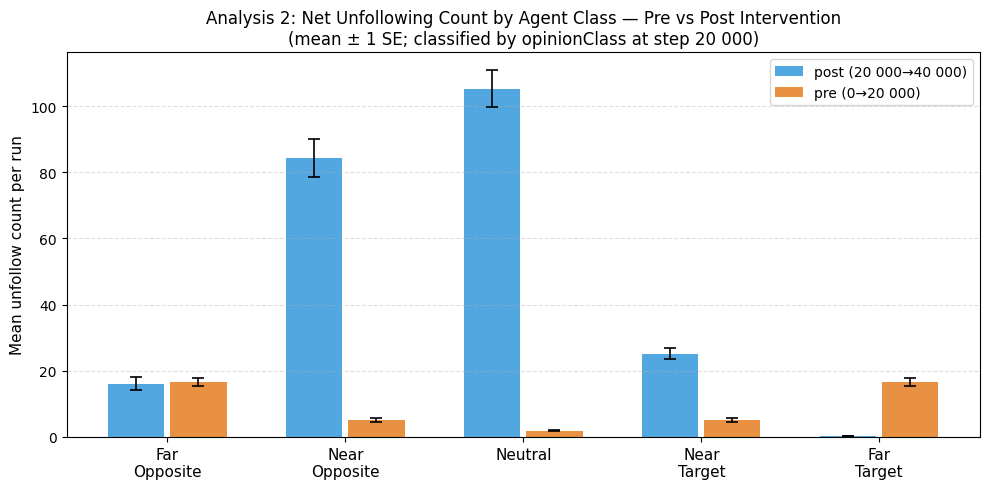

Saved: results/summary/unfollow_count_by_class.png

Mean ± SE of unfollow count per run by group and window:

  post (20 000→40 000):
    far_opposite      mean=16.07  SE=1.96
    near_opposite     mean=84.26  SE=5.72
    neutral           mean=105.32  SE=5.46
    near_target       mean=25.21  SE=1.79
    far_target        mean=0.22  SE=0.06

  pre (0→20 000):
    far_opposite      mean=16.64  SE=1.25
    near_opposite     mean=5.15  SE=0.53
    neutral           mean=1.91  SE=0.17
    near_target       mean=5.15  SE=0.53
    far_target        mean=16.64  SE=1.25


In [44]:
# ---------------------------------------------------------------------------
# Analysis 2: Net unfollowing count by class
#   pre  = agents who followed at step 0 but NOT at step 20 000
#   post = agents who followed at step 20 000 but NOT at step 40 000
# Comparison windows (0-20 000 vs 20 000-40 000) are equal-length for fair
# comparison.  Unfollowers are classified by their opinionClass at step 20 000
# (the last pre-intervention snapshot) mapped to direction-relative groups.
# ---------------------------------------------------------------------------
unfollow_records = []
print('Analysis 2: collecting unfollow counts ...')

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m: continue
    seed, target_sign = int(m.group(1)), float(m.group(2))
    if seed not in set(SEEDS): continue

    fp_20k = _gexf_path(run_dir, 20000)
    if not fp_20k: continue
    G_20k, target_ids, agents_20k = _parse_gexf_full(fp_20k)
    if not target_ids or G_20k is None: continue
    tid = target_ids[0]

    def _cls(nid):
        oc = agents_20k.get(nid, {}).get('opinionclass', -1)
        return _POS_MAP[target_sign].get(oc, 'unknown') if oc in range(5) else 'unknown'

    fol_20k = set(G_20k.predecessors(tid)) if tid in G_20k else set()

    fp_0 = _gexf_path(run_dir, 0)
    fol_0 = set()
    if fp_0:
        G_0, _, _ = _parse_gexf_full(fp_0)
        if G_0 is not None and tid in G_0:
            fol_0 = set(G_0.predecessors(tid))

    fp_40k = _gexf_path(run_dir, 40000)
    fol_40k = set()
    if fp_40k:
        G_40k, _, _ = _parse_gexf_full(fp_40k)
        if G_40k is not None and tid in G_40k:
            fol_40k = set(G_40k.predecessors(tid))

    for window, unfol in [('pre (0→20 000)',        fol_0   - fol_20k),
                           ('post (20 000→40 000)',  fol_20k - fol_40k)]:
        counts = {g: 0 for g in GROUP_ORDER}
        for nid in unfol:
            grp = _cls(nid)
            if grp in counts:
                counts[grp] += 1
        for grp in GROUP_ORDER:
            unfollow_records.append({
                'seed': seed, 'target_sign': target_sign,
                'window': window, 'relative_group': grp, 'count': counts[grp],
            })

df_unfollow = pd.DataFrame(unfollow_records)
_gb_uf = df_unfollow.groupby(['window', 'relative_group'])['count']
pivot_uf    = _gb_uf.mean().unstack('relative_group')[GROUP_ORDER]
pivot_uf_se = _gb_uf.sem() .unstack('relative_group')[GROUP_ORDER]

_ekw = dict(elinewidth=1.2, ecolor='k', capthick=1.2)
x = np.arange(len(GROUP_ORDER))
windows_uf = list(pivot_uf.index)
width = 0.7 / len(windows_uf)
colors_uf = ['#3498db', '#e67e22']

fig, ax = plt.subplots(figsize=(10, 5))
for wi, (win, color) in enumerate(zip(windows_uf, colors_uf)):
    offset = (wi - (len(windows_uf) - 1) / 2) * width
    ax.bar(x + offset, pivot_uf.loc[win].values, width * 0.9,
           yerr=pivot_uf_se.loc[win].values, capsize=4, error_kw=_ekw,
           label=win, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, fontsize=11)
ax.set_ylabel('Mean unfollow count per run', fontsize=11)
ax.set_title(
    'Analysis 2: Net Unfollowing Count by Agent Class — Pre vs Post Intervention\n'
    '(mean \u00b1 1 SE; classified by opinionClass at step 20 000)',
    fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'summary', 'unfollow_count_by_class.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: results/summary/unfollow_count_by_class.png')
print('\nMean \u00b1 SE of unfollow count per run by group and window:')
for win in windows_uf:
    print(f'\n  {win}:')
    for grp in GROUP_ORDER:
        print(f'    {grp:16s}  mean={pivot_uf.loc[win, grp]:.2f}  SE={pivot_uf_se.loc[win, grp]:.2f}')


Analysis 3: counting agents with increased posting prob by class ...


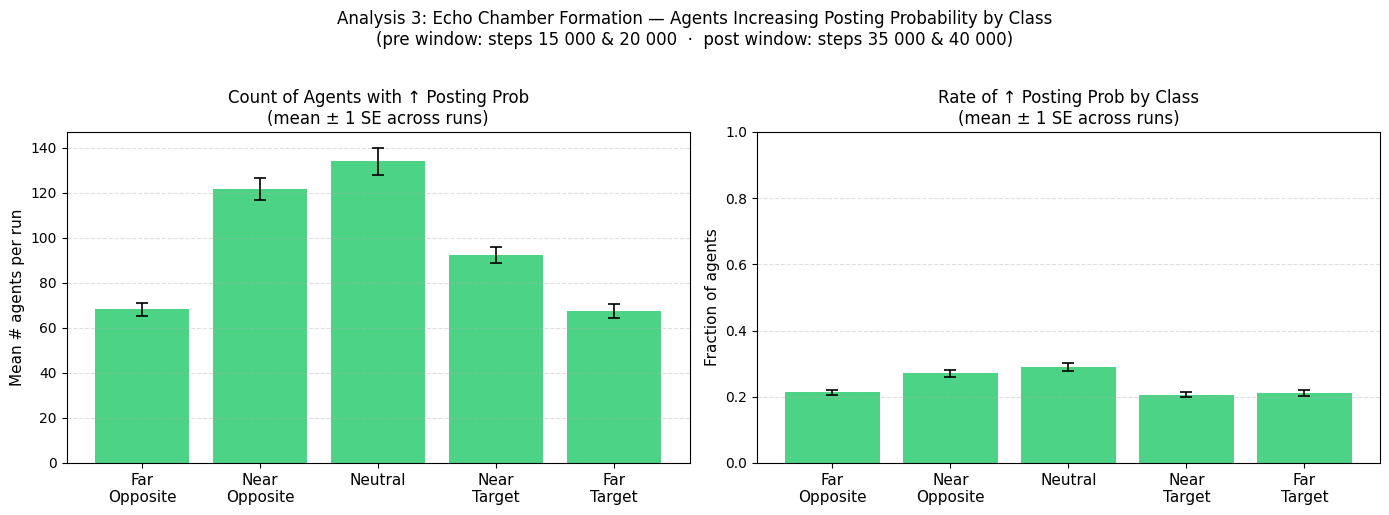

Saved: results/summary/posting_prob_increase_by_class.png

Mean ± SE — agents increasing posting prob by relative group:
  far_opposite      count=68.2 ± 2.92  rate=0.2129 ± 0.0086
  near_opposite     count=121.5 ± 4.83  rate=0.2702 ± 0.0102
  neutral           count=133.9 ± 6.05  rate=0.2892 ± 0.0113
  near_target       count=92.3 ± 3.53  rate=0.2054 ± 0.0074
  far_target        count=67.4 ± 2.99  rate=0.2117 ± 0.0096


In [45]:
# ---------------------------------------------------------------------------
# Analysis 3: Echo Chamber Formation — Agents Increasing Posting Probability
#             by direction-relative class, around manipulation step 20 000
#
# For each non-target agent, windowed-average postprob is computed:
#   pre  window: steps 15 000 & 20 000  (nearest snapshots before/at intervention)
#   post window: steps 35 000 & 40 000  (nearest snapshots near simulation end)
# An agent "increases" if post_window_avg > pre_window_avg.
# Counts and rates of such agents are tallied per direction-relative class,
# then averaged across runs with ±1 SE.
# ---------------------------------------------------------------------------
_A3_PRE_STEPS  = [15000, 20000]
_A3_POST_STEPS = [35000, 40000]

a3_records = []
print('Analysis 3: counting agents with increased posting prob by class ...')

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m: continue
    seed, target_sign = int(m.group(1)), float(m.group(2))
    if seed not in set(SEEDS): continue

    rows = compute_run_agent_deltas(run_dir, _A3_PRE_STEPS, _A3_POST_STEPS,
                                    class_ref_step=15000, target_ref_step=20000)
    if not rows: continue

    for r in rows:
        grp = _POS_MAP[target_sign].get(r['opinionclass'], 'unknown')
        if grp not in GROUP_ORDER: continue
        a3_records.append({
            'seed':           seed,
            'target_sign':    target_sign,
            'relative_group': grp,
            'pre_postprob':   r['pre_postprob'],
            'post_postprob':  r['post_postprob'],
            'increased':      int(r['post_postprob'] > r['pre_postprob']),
        })

df_a3 = pd.DataFrame(a3_records)

# Per-run x class: count and rate of agents increasing postprob
a3_run_grp = df_a3.groupby(['seed', 'relative_group'])
a3_count   = a3_run_grp['increased'].sum().rename('n_increased')
a3_total   = a3_run_grp['increased'].count().rename('n_total')
a3_rate    = (a3_count / a3_total).rename('rate')
df_a3_run  = pd.concat([a3_count, a3_total, a3_rate], axis=1).reset_index()
df_a3_run  = df_a3_run[df_a3_run['relative_group'].isin(GROUP_ORDER)]

# Aggregate across runs
agg_count    = df_a3_run.groupby('relative_group')['n_increased']
agg_rate     = df_a3_run.groupby('relative_group')['rate']
pivot_cnt    = agg_count.mean().reindex(GROUP_ORDER)
pivot_cnt_se = agg_count.sem() .reindex(GROUP_ORDER)
pivot_rate   = agg_rate.mean() .reindex(GROUP_ORDER)
pivot_rate_se= agg_rate.sem()  .reindex(GROUP_ORDER)

_ekw  = dict(elinewidth=1.2, ecolor='k', capthick=1.2)
x     = np.arange(len(GROUP_ORDER))
color = '#2ecc71'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(x, pivot_cnt.values, yerr=pivot_cnt_se.values, capsize=4,
       error_kw=_ekw, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, fontsize=11)
ax.set_ylabel('Mean # agents per run', fontsize=11)
ax.set_title('Count of Agents with ↑ Posting Prob\n(mean ± 1 SE across runs)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax = axes[1]
ax.bar(x, pivot_rate.values, yerr=pivot_rate_se.values, capsize=4,
       error_kw=_ekw, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, fontsize=11)
ax.set_ylabel('Fraction of agents', fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Rate of ↑ Posting Prob by Class\n(mean ± 1 SE across runs)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(
    'Analysis 3: Echo Chamber Formation — Agents Increasing Posting Probability by Class\n'
    '(pre window: steps 15 000 & 20 000  ·  post window: steps 35 000 & 40 000)',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'summary', 'posting_prob_increase_by_class.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: results/summary/posting_prob_increase_by_class.png')

print('\nMean ± SE — agents increasing posting prob by relative group:')
for grp in GROUP_ORDER:
    print(f'  {grp:16s}  count={pivot_cnt[grp]:.1f} ± {pivot_cnt_se[grp]:.2f}'
          f'  rate={pivot_rate[grp]:.4f} ± {pivot_rate_se[grp]:.4f}')

---
## Section 2: Classification by Backfire Direction (Both / One / Neither)

We classify each seed by whether backfire occurs in *both*, *one*, or *neither* manipulation direction.

**"Both-direction backfire" is theoretically the cleanest signal**: it is invariant to the direction-of-manipulation confound. A target that generates counter-mobilisation regardless of which way it is pushed must possess some structural property that guarantees the reaction — independent of the opinion asymmetry in the broader network.

We compare structural metrics between the **both** group and the **rest** using Mann-Whitney U (distribution-free) and the rank-biserial correlation *r* as effect size.

In [46]:
# ---------------------------------------------------------------------------
# Classify seeds by backfire robustness
# ---------------------------------------------------------------------------
paired = {}
for _, row in df.iterrows():
    seed = row['seed']
    if seed not in paired:
        paired[seed] = {}
    paired[seed][row['target_sign']] = row

def classify_seed(d):
    if -1.0 not in d or 1.0 not in d:
        return None
    b_neg = d[-1.0]['backfire_effect']
    b_pos = d[1.0]['backfire_effect']
    if b_neg > 0 and b_pos > 0:
        return 'both'
    elif b_neg <= 0 and b_pos <= 0:
        return 'neither'
    else:
        return 'one'

seed_class = {s: classify_seed(d) for s, d in paired.items() if classify_seed(d) is not None}
print("Seed classification:")
for label in ['both', 'one', 'neither']:
    seeds = [s for s, c in seed_class.items() if c == label]
    print(f"  {label:8s}: {len(seeds)} seeds")

# Build seed-level summary frame (structural metrics same for both dirs, use dir=-1 row)
def make_seed_row(seed, d):
    base = dict(d[-1.0])
    base['backfire_neg']  = d[-1.0]['backfire_effect']
    base['backfire_pos']  = d[1.0]['backfire_effect']
    base['mean_backfire'] = (d[-1.0]['backfire_effect'] + d[1.0]['backfire_effect']) / 2
    base['backfire_class'] = seed_class[seed]
    return base

df_seeds = pd.DataFrame([make_seed_row(s, paired[s])
                         for s in seed_class if seed_class[s] is not None])
print(f"\nSeed-level frame: {len(df_seeds)} rows")
print(df_seeds.groupby('backfire_class')['in_degree'].describe()[['count', '50%', 'mean', 'std']])

Seed classification:
  both    : 32 seeds
  one     : 36 seeds
  neither : 0 seeds

Seed-level frame: 68 rows
                count    50%        mean         std
backfire_class                                      
both             32.0  295.0  330.656250  197.555645
one              36.0  157.5  296.027778  227.365217


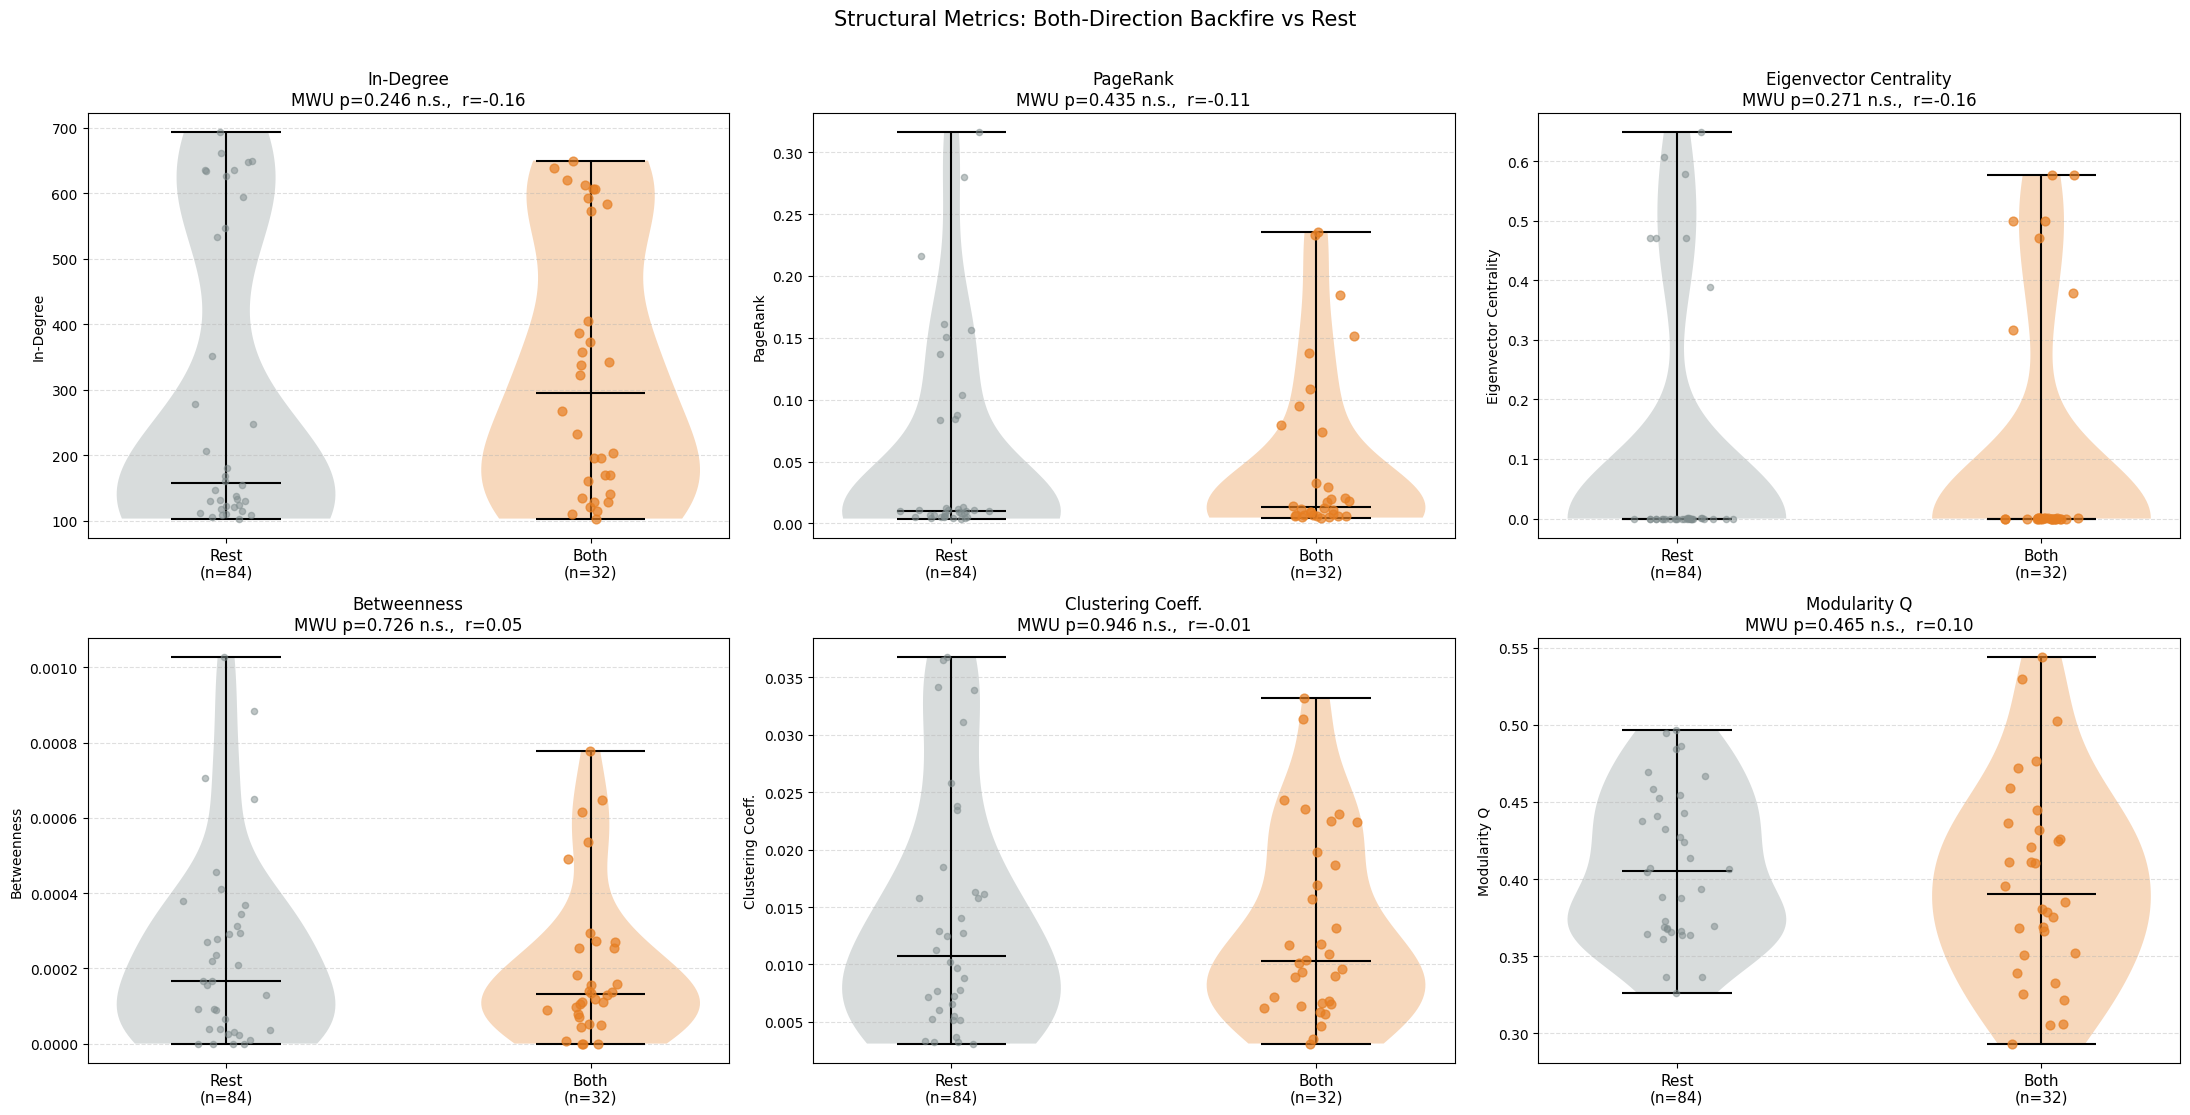

Saved: results/summary/both_backfire_structure.png


In [47]:
# ---------------------------------------------------------------------------
# Fig 1: Structural metric distributions — both vs rest (violin + strip)
# ---------------------------------------------------------------------------
from scipy import stats as sp_stats

both_df = df_seeds[df_seeds['backfire_class'] == 'both']
rest_df = df_seeds[df_seeds['backfire_class'] != 'both']

METRICS_COMPARE = [
    ('in_degree',   'In-Degree'),
    ('pagerank',    'PageRank'),
    ('eigenvector', 'Eigenvector Centrality'),
    ('betweenness', 'Betweenness'),
    ('clustering',  'Clustering Coeff.'),
    ('modularity',  'Modularity Q'),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 11))
axes = axes.flatten()
palette = {'both': '#e67e22', 'rest': '#7f8c8d'}

for ax, (metric, label) in zip(axes, METRICS_COMPARE):
    a = both_df[metric].dropna().values
    b = rest_df[metric].dropna().values

    # violin
    parts = ax.violinplot([b, a], positions=[0, 1], showmedians=True, widths=0.6)
    parts['bodies'][0].set_facecolor(palette['rest'])
    parts['bodies'][1].set_facecolor(palette['both'])
    for p in ['cmedians','cbars','cmins','cmaxes']:
        parts[p].set_color('black')

    # strip jitter
    ax.scatter(np.random.normal(0, 0.05, len(b)), b,
               color=palette['rest'], alpha=0.5, s=20, zorder=3)
    ax.scatter(np.random.normal(1, 0.05, len(a)), a,
               color=palette['both'], alpha=0.7, s=40, zorder=3)

    U, p = sp_stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - 2*U / (len(a) * len(b))
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    ax.set_title(f'{label}\nMWU p={p:.3f} {sig},  r={r:.2f}', fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Rest\n(n=84)', f'Both\n(n={len(a)})'], fontsize=11)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Structural Metrics: Both-Direction Backfire vs Rest', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "both_backfire_structure.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/both_backfire_structure.png")

/tmp/ipykernel_1197320/3844544512.py:13: RuntimeWarning: invalid value encountered in scalar divide
  or_ = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))


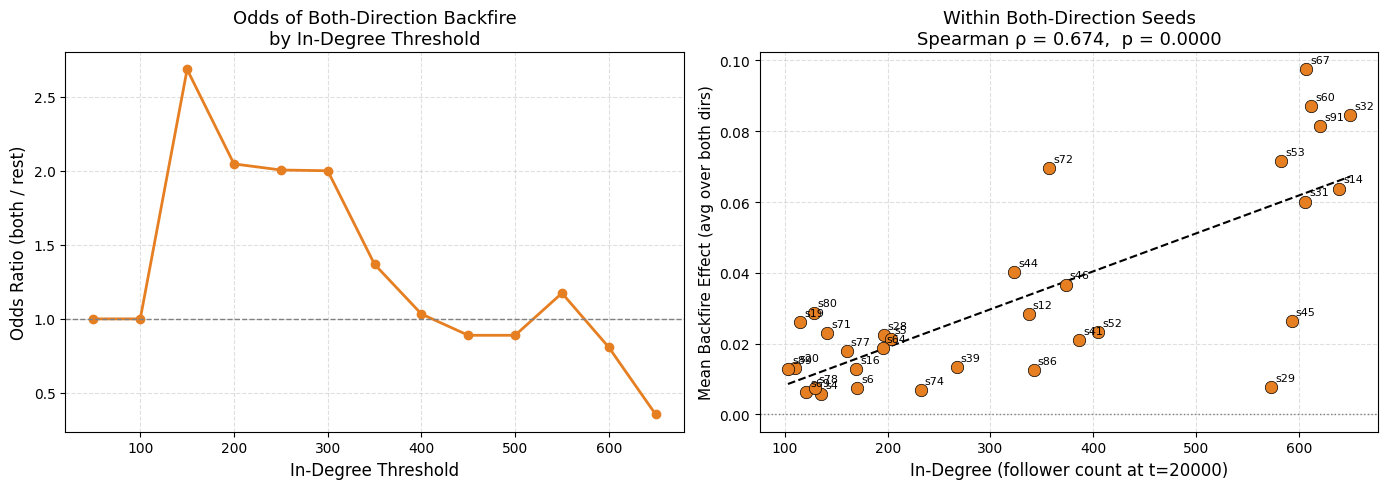

Saved: results/summary/both_backfire_threshold.png

In-degree threshold — fraction above threshold & odds ratio
 threshold  both_frac  rest_frac         OR
       100      1.000      1.000       1.00
       200      0.594      0.417       2.05
       300      0.500      0.333       2.00
       400      0.312      0.306       1.03
       500      0.281      0.306       0.89


In [48]:
# ---------------------------------------------------------------------------
# Fig 2: In-degree threshold odds-ratio curve + within-both scatter
# ---------------------------------------------------------------------------
fig, (ax_or, ax_sc) = plt.subplots(1, 2, figsize=(14, 5))

# -- Odds-ratio curve --
thresholds = list(range(50, 850, 50))
ors = []
for t in thresholds:
    f_b = (both_df['in_degree'] >= t).mean()
    f_r = (rest_df['in_degree'] >= t).mean()
    eps = 1e-9
    or_ = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))
    ors.append(or_)

ax_or.plot(thresholds, ors, 'o-', color='#e67e22', linewidth=2)
ax_or.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax_or.set_xlabel('In-Degree Threshold', fontsize=12)
ax_or.set_ylabel('Odds Ratio (both / rest)', fontsize=12)
ax_or.set_title('Odds of Both-Direction Backfire\nby In-Degree Threshold', fontsize=13)
ax_or.grid(True, linestyle='--', alpha=0.4)

# -- Scatter: within both-backfire, in_degree vs mean_backfire --
rho, p = sp_stats.spearmanr(both_df['in_degree'], both_df['mean_backfire'])
ax_sc.scatter(both_df['in_degree'], both_df['mean_backfire'],
              color='#e67e22', s=80, zorder=3, edgecolors='k', linewidths=0.5)

# label each seed
for _, row in both_df.iterrows():
    ax_sc.annotate(f"s{int(row['seed'])}", (row['in_degree'], row['mean_backfire']),
                   fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                   textcoords='offset points')

slope, intercept, *_ = sp_stats.linregress(both_df['in_degree'].values,
                                            both_df['mean_backfire'].values)
x_line = np.linspace(both_df['in_degree'].min(), both_df['in_degree'].max(), 200)
ax_sc.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)
ax_sc.axhline(0, color='gray', linestyle=':', linewidth=1)
ax_sc.set_xlabel('In-Degree (follower count at t=20000)', fontsize=12)
ax_sc.set_ylabel('Mean Backfire Effect (avg over both dirs)', fontsize=11)
ax_sc.set_title(f'Within Both-Direction Seeds\nSpearman ρ = {rho:.3f},  p = {p:.4f}', fontsize=13)
ax_sc.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "both_backfire_threshold.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/both_backfire_threshold.png")

# In-degree threshold table
print("\nIn-degree threshold — fraction above threshold & odds ratio")
print(f"{'threshold':>10} {'both_frac':>10} {'rest_frac':>10} {'OR':>10}")
for t in [100, 200, 300, 400, 500]:
    f_b = (both_df['in_degree'] >= t).mean()
    f_r = (rest_df['in_degree'] >= t).mean()
    eps = 1e-9
    OR = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))
    print(f"{t:>10} {f_b:>10.3f} {f_r:>10.3f} {OR:>10.2f}")

In [49]:
# ---------------------------------------------------------------------------
# Optional: save the per-run metrics table for further analysis
# ---------------------------------------------------------------------------
out_path = os.path.join(RESULTS_DIR, "summary", "structural_backfire_table.csv")
df.to_csv(out_path, index=False)
print(f"Per-run table saved to {out_path}")
df

Per-run table saved to ./results/summary/structural_backfire_table.csv


,run_id,seed,target_sign,target_id,n_targets,backfire_effect,modularity,in_degree,betweenness,clustering,pagerank,eigenvector,target_opinion,follower_mean_opinion,follower_opinion_std,follower_homophily_frac,follower_dir_alignment
0,run_10_dir_-1.0,10,-1.0,2,1,-0.019195,0.369527,626.0,0.000651,0.006077,0.150586,0.471427,0.088838,-0.013396,0.363672,0.544728,0.455272
1,run_10_dir_1.0,10,1.0,2,1,0.131769,0.369527,626.0,0.000651,0.006077,0.150586,0.471427,0.088838,-0.013396,0.363672,0.544728,0.544728
2,run_11_dir_-1.0,11,-1.0,2,1,0.092282,0.454370,661.0,0.000457,0.003353,0.280361,0.606863,-0.107086,-0.043752,0.399223,0.577912,0.577912
3,run_11_dir_1.0,11,1.0,2,1,-0.007931,0.454370,661.0,0.000457,0.003353,0.280361,0.606863,-0.107086,-0.043752,0.399223,0.577912,0.422088
4,run_12_dir_-1.0,12,-1.0,5,1,0.015153,0.472142,337.0,0.000271,0.006172,0.020077,0.000323,-0.194500,-0.270618,0.367457,0.768546,0.768546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,run_91_dir_1.0,91,1.0,0,1,0.154012,0.306004,621.0,0.000255,0.009613,0.095255,0.316679,-0.118117,0.063443,0.350377,0.391304,0.608696
132,run_95_dir_-1.0,95,-1.0,5,1,NaN,0.388445,109.0,0.000030,0.010175,0.005661,0.000010,0.170852,-0.051639,0.345916,0.403670,0.596330
133,run_95_dir_1.0,95,1.0,5,1,NaN,0.388445,109.0,0.000030,0.010175,0.005661,0.000010,0.190852,-0.051639,0.345916,0.403670,0.403670
134,run_9_dir_-1.0,9,-1.0,10,1,-0.013447,0.336843,147.0,0.000157,0.034185,0.009610,0.000026,0.037264,0.028245,0.297617,0.571429,0.428571


## Agent-Level Changes in Opinion and Posting Probability Around Manipulation (Step 20000)

For each non-target agent we compute per-run averages:

| Window | Steps averaged |
|---|---|
| **pre** | 10000, 15000, 20000 — steady state just before manipulation |
| **post** | 20000, 25000, 30000 — immediate response to manipulation |

Metrics:
- **Δpostprob** = post_mean − pre_mean of `postProb` (positive = agent became more active)
- **Δopinion**  = post_mean − pre_mean of `opinion` (shift in expressed opinion)

**Opinion class is read from step 15000** (last GEXF snapshot before manipulation starts).  
Agents are grouped into **5 direction-relative positions**, ordered from most-opposing to most-aligned:

| Relative label | dir = +1 | dir = −1 |
|---|---|---|
| `far_opposite`  | bin 0 | bin 4 |
| `near_opposite` | bin 1 | bin 3 |
| `neutral`       | bin 2 | bin 2 |
| `near_target`   | bin 3 | bin 1 |
| `far_target`    | bin 4 | bin 0 |

The manipulated target node is **excluded** (its changes are externally forced).  
Each seed contributes two runs (dir = −1 and +1), both pooled within the seed's backfire class.

Since medians of Δpostprob are zero for all groups (most agents do not change at all), four complementary approaches are used to detect tail-driven counter-mobilisation:

1. **Activation rate** — fraction of agents with Δpostprob > threshold; Fisher's exact test (both vs rest per group)
2. **Upper quantiles** — 75th / 90th / 95th percentile of Δpostprob by group × class (sensitive to tail divergence invisible in box plots)
3. **KS test on full distributions** — Kolmogorov-Smirnov comparing both vs rest per group; ECDF plots
5. **Top-mover composition** — which groups are over-represented among the top 5% Δpostprob agents?

In [50]:
# ---------------------------------------------------------------------------
# Build per-agent delta dataframe across all valid runs
# ---------------------------------------------------------------------------
PRE_STEPS  = [10000, 15000, 20000]   # average window before manipulation
POST_STEPS = [20000, 25000, 30000]   # average window after manipulation starts

agent_records = []

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m:
        continue
    seed        = int(m.group(1))
    target_sign = float(m.group(2))

    if SEEDS is not None and seed not in SEEDS:
        continue
    if seed not in seed_class:
        continue  # no valid target or missing paired direction

    bclass = seed_class[seed]
    print(f"  {dirname}  [{bclass}] ...", end=" ")

    rows = compute_run_agent_deltas(run_dir, PRE_STEPS, POST_STEPS)
    if not rows:
        print("no data")
        continue

    for r in rows:
        r.update({
            'seed':           seed,
            'run_id':         dirname,
            'target_sign':    target_sign,
            'backfire_class': bclass,
            'relative_group': get_relative_group(r['opinionclass'], target_sign),
        })
    agent_records.extend(rows)
    print(f"{len(rows)} agents")

df_agents = pd.DataFrame(agent_records)
df_agents = df_agents[df_agents['opinionclass'].between(0, 4)]
print(f"\nTotal agent-run records: {len(df_agents)}")
print("\nMedian Δ by backfire class × relative group:")
print(df_agents.groupby(['backfire_class', 'relative_group'])[
    ['delta_opinion', 'delta_postprob']].median().round(4))

  run_10_dir_-1.0  [one] ... 999 agents
  run_10_dir_1.0  [one] ... 999 agents
  run_11_dir_-1.0  [one] ... 999 agents
  run_11_dir_1.0  [one] ... 999 agents
  run_12_dir_-1.0  [both] ... 999 agents
  run_12_dir_1.0  [both] ... 999 agents
  run_14_dir_-1.0  [both] ... 999 agents
  run_14_dir_1.0  [both] ... 999 agents
  run_15_dir_-1.0  [one] ... 999 agents
  run_15_dir_1.0  [one] ... 999 agents
  run_16_dir_-1.0  [both] ... 999 agents
  run_16_dir_1.0  [both] ... 999 agents
  run_17_dir_-1.0  [one] ... 999 agents
  run_17_dir_1.0  [one] ... 999 agents
  run_19_dir_-1.0  [both] ... 999 agents
  run_19_dir_1.0  [both] ... 999 agents
  run_1_dir_-1.0  [one] ... 999 agents
  run_1_dir_1.0  [one] ... 999 agents
  run_20_dir_-1.0  [both] ... 999 agents
  run_20_dir_1.0  [both] ... 999 agents
  run_22_dir_-1.0  [one] ... 999 agents
  run_22_dir_1.0  [one] ... 999 agents
  run_24_dir_-1.0  [one] ... 999 agents
  run_24_dir_1.0  [one] ... 999 agents
  run_26_dir_-1.0  [one] ... 999 agents
  ru

=== Method 1: Activation rate (Δpostprob > 0.01) ===
relative_group  far_opposite  near_opposite  neutral  near_target  far_target
backfire_class                                                               
both                  0.0606         0.1183   0.1361       0.0805      0.0541
one                   0.0537         0.0947   0.1356       0.0725      0.0572
neither                  NaN            NaN      NaN          NaN         NaN

Fisher's exact — both vs rest, per relative group:
  far_opposite      OR=1.136  p=0.0301  *  (both=0.0606, rest=0.0537)
  near_opposite     OR=1.283  p=0.0000  **  (both=0.1183, rest=0.0947)
  neutral           OR=1.004  p=0.9082  n.s.  (both=0.1361, rest=0.1356)
  near_target       OR=1.121  p=0.0083  **  (both=0.0805, rest=0.0725)
  far_target        OR=0.942  p=0.3286  n.s.  (both=0.0541, rest=0.0572)


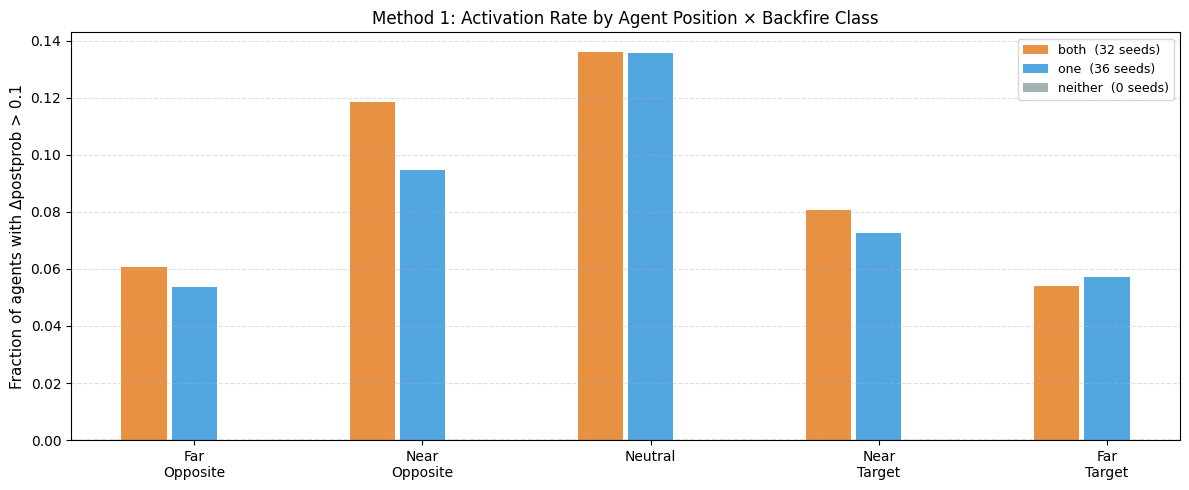

Saved: results/summary/method1_activation_rate.png

=== Method 2: Upper quantiles of Δpostprob ===
relative_group       far_opposite  near_opposite   neutral  near_target  far_target
backfire_class                                                                     
both           0.75      0.000000       0.002985  0.004871     0.000000    0.000000
               0.90      0.031667       0.133775  0.146500     0.053018    0.019833
               0.95      0.130421       0.224896  0.215294     0.150000    0.109778
one            0.75      0.000000       0.001667  0.005755     0.000000    0.000000
               0.90      0.031667       0.084129  0.148333     0.043329    0.031084
               0.95      0.110055       0.196625  0.237448     0.145009    0.118669


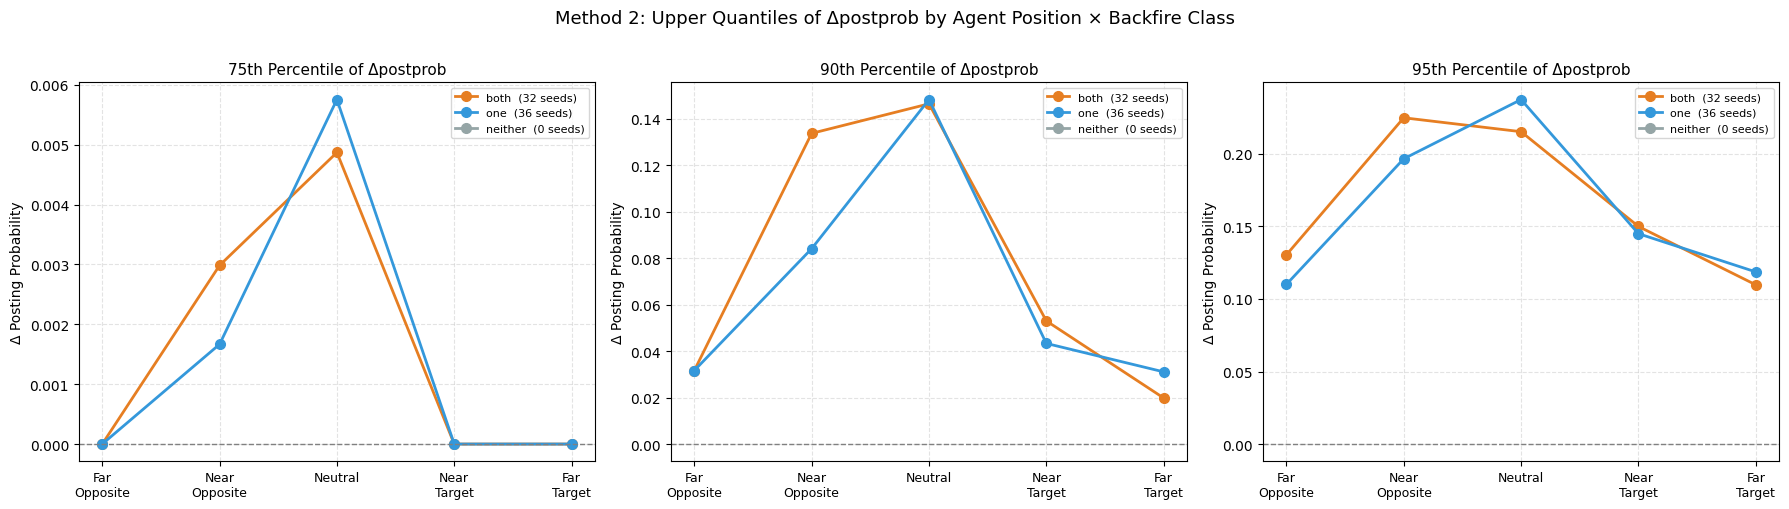

Saved: results/summary/method2_upper_quantiles.png

=== Method 3: KS test — both vs rest, per relative group ===
  far_opposite      KS=0.0111  p=0.5187  n.s.
  near_opposite     KS=0.0291  p=0.0000  **
  neutral           KS=0.0119  p=0.2112  n.s.
  near_target       KS=0.0144  p=0.0867  n.s.
  far_target        KS=0.0173  p=0.0771  n.s.


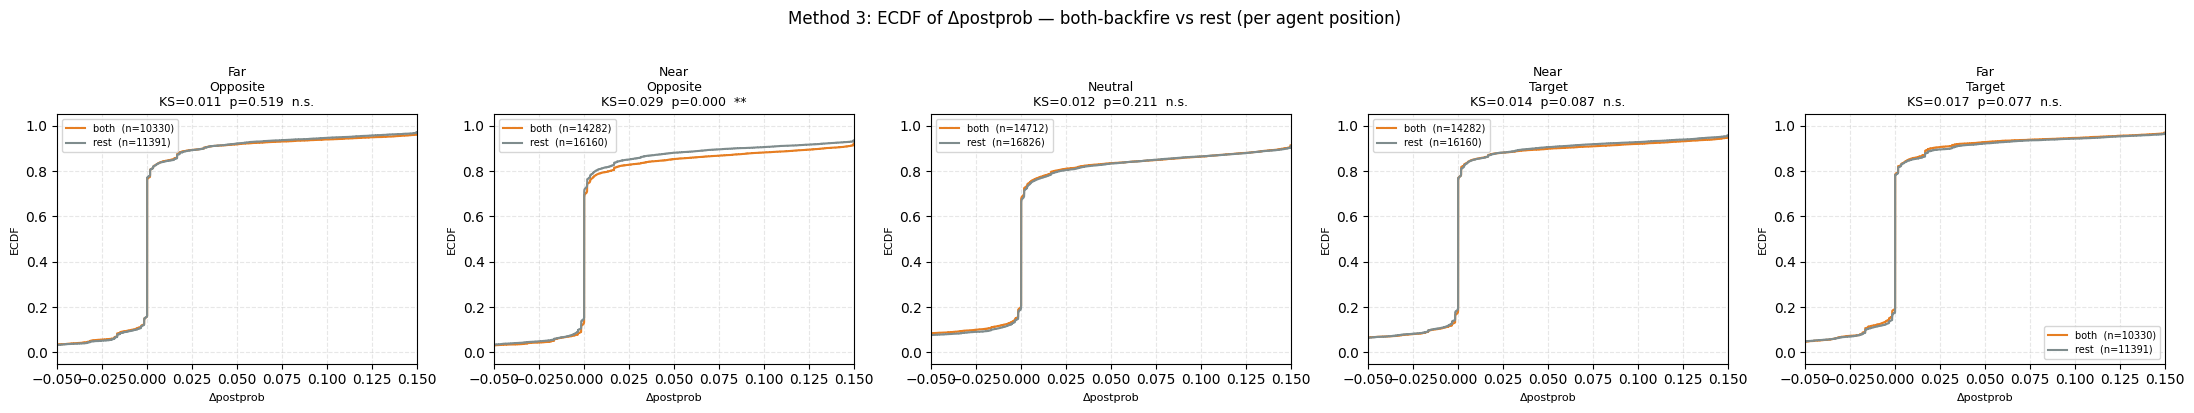

Saved: results/summary/method3_ks_ecdf.png

=== Method 5: Group composition of top 5% Δpostprob movers (n=6793) ===

Fraction within top movers (row-normalised):
relative_group  far_opposite  near_opposite  neutral  near_target  far_target
backfire_class                                                               
both                   0.109          0.297    0.328        0.177        0.09
one                    0.084          0.275    0.377        0.174        0.09

Chi-square on group composition of top movers: χ²=25.904  df=4  p=0.0000  **
Fisher's exact — far_opposite enrichment (both vs rest): OR=1.340  p=0.0004  **


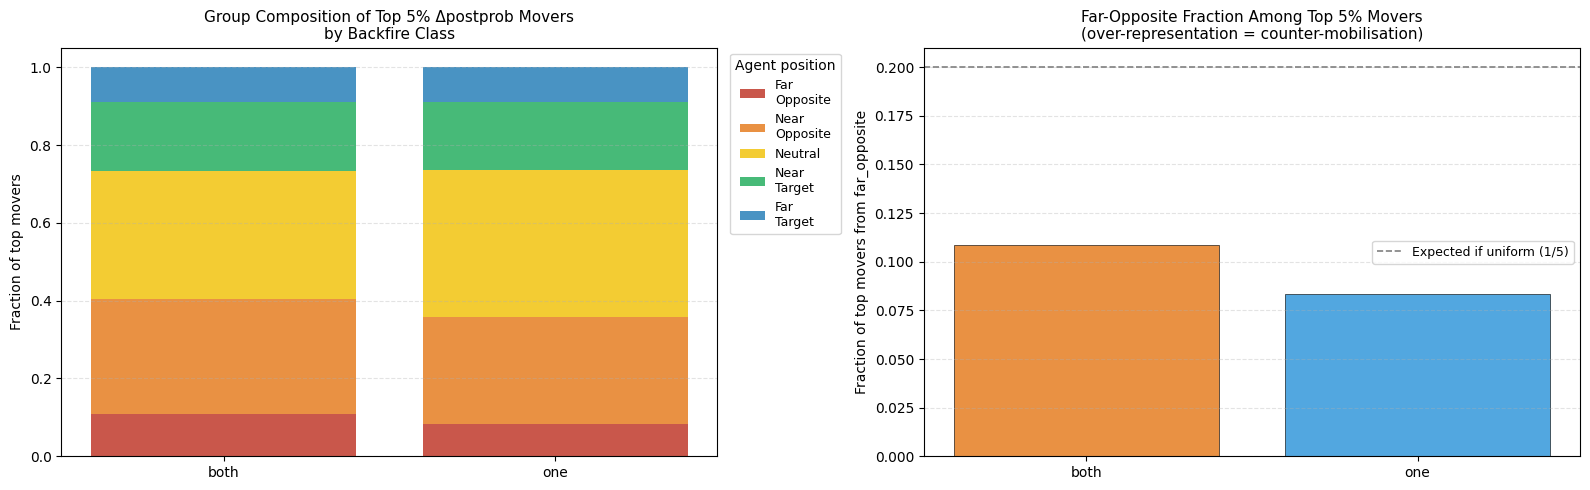

Saved: results/summary/method5_top_movers_composition.png


In [51]:
from scipy.stats import fisher_exact, ks_2samp, chi2_contingency

GROUP_ORDER  = ['far_opposite', 'near_opposite', 'neutral', 'near_target', 'far_target']
GROUP_LABELS = ['Far\nOpposite', 'Near\nOpposite', 'Neutral', 'Near\nTarget', 'Far\nTarget']
CLASS_ORDER  = ['both', 'one', 'neither']
CLASS_COLORS = {'both': '#e67e22', 'one': '#3498db', 'neither': '#95a5a6'}
n_seeds_cls  = df_agents.groupby('backfire_class')['seed'].nunique().to_dict()

ng = len(GROUP_ORDER)
nc = len(CLASS_ORDER)

# =========================================================================
# Method 1: Activation rate + Fisher's exact test
# =========================================================================
ACTIVATION_THRESHOLD = 0.1
df_agents['activated'] = df_agents['delta_postprob'] > ACTIVATION_THRESHOLD

act_rate = (
    df_agents.groupby(['backfire_class', 'relative_group'])['activated']
    .mean()
    .unstack('relative_group')[GROUP_ORDER]
)
print("=== Method 1: Activation rate (Δpostprob > 0.01) ===")
print(act_rate.reindex(CLASS_ORDER).round(4).to_string())

print("\nFisher's exact — both vs rest, per relative group:")
for grp in GROUP_ORDER:
    sub      = df_agents[df_agents['relative_group'] == grp]
    b_act    = sub[sub['backfire_class'] == 'both']['activated']
    r_act    = sub[sub['backfire_class'] != 'both']['activated']
    table    = np.array([[b_act.sum(), len(b_act) - b_act.sum()],
                         [r_act.sum(), len(r_act) - r_act.sum()]])
    or_, p   = fisher_exact(table, alternative='two-sided')
    sig      = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    print(f"  {grp:16s}  OR={or_:.3f}  p={p:.4f}  {sig}  "
          f"(both={b_act.mean():.4f}, rest={r_act.mean():.4f})")

width   = 0.22
offsets = np.linspace(-(nc - 1) / 2 * width, (nc - 1) / 2 * width, nc)

fig, ax = plt.subplots(figsize=(12, 5))
for ci, cls in enumerate(CLASS_ORDER):
    sub   = df_agents[df_agents['backfire_class'] == cls]
    rates = [sub[sub['relative_group'] == grp]['activated'].mean() for grp in GROUP_ORDER]
    ax.bar(np.arange(ng) + offsets[ci], rates, width=width * 0.9,
           color=CLASS_COLORS[cls],
           label=f'{cls}  ({n_seeds_cls.get(cls, 0)} seeds)', alpha=0.85)
ax.set_xticks(range(ng))
ax.set_xticklabels(GROUP_LABELS, fontsize=10)
ax.set_ylabel(f'Fraction of agents with Δpostprob > {ACTIVATION_THRESHOLD}', fontsize=11)
ax.set_title('Method 1: Activation Rate by Agent Position × Backfire Class', fontsize=12)
ax.legend(fontsize=9)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "method1_activation_rate.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/method1_activation_rate.png")

# =========================================================================
# Method 2: Upper-quantile comparison (75th / 90th / 95th percentile)
# =========================================================================
QUANTILES = [0.75, 0.90, 0.95]
print("\n=== Method 2: Upper quantiles of Δpostprob ===")
qtab = (
    df_agents.groupby(['backfire_class', 'relative_group'])['delta_postprob']
    .quantile(QUANTILES)
    .unstack('relative_group')[GROUP_ORDER]
)
print(qtab.to_string())

fig, axes = plt.subplots(1, len(QUANTILES), figsize=(18, 5), sharey=False)
for ax, q in zip(axes, QUANTILES):
    for cls in CLASS_ORDER:
        vals = [
            df_agents[
                (df_agents['backfire_class'] == cls) &
                (df_agents['relative_group']  == grp)
            ]['delta_postprob'].quantile(q)
            for grp in GROUP_ORDER
        ]
        ax.plot(range(ng), vals, 'o-', color=CLASS_COLORS[cls],
                label=f'{cls}  ({n_seeds_cls.get(cls, 0)} seeds)',
                linewidth=2, markersize=7)
    ax.set_xticks(range(ng))
    ax.set_xticklabels(GROUP_LABELS, fontsize=9)
    ax.set_title(f'{int(q * 100)}th Percentile of Δpostprob', fontsize=11)
    ax.set_ylabel('Δ Posting Probability', fontsize=10)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.35)
plt.suptitle('Method 2: Upper Quantiles of Δpostprob by Agent Position × Backfire Class',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "method2_upper_quantiles.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/method2_upper_quantiles.png")

# =========================================================================
# Method 3: Kolmogorov-Smirnov test — full distribution comparison
# =========================================================================
print("\n=== Method 3: KS test — both vs rest, per relative group ===")

fig, axes = plt.subplots(1, ng, figsize=(22, 4), sharey=False)
for ax, grp, label in zip(axes, GROUP_ORDER, GROUP_LABELS):
    both_vals = df_agents[
        (df_agents['backfire_class'] == 'both') &
        (df_agents['relative_group']  == grp)
    ]['delta_postprob'].dropna().values
    rest_vals = df_agents[
        (df_agents['backfire_class'] != 'both') &
        (df_agents['relative_group']  == grp)
    ]['delta_postprob'].dropna().values

    stat, p = ks_2samp(both_vals, rest_vals)
    sig     = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    print(f"  {grp:16s}  KS={stat:.4f}  p={p:.4f}  {sig}")

    for vals, cls, color in [
        (both_vals, 'both', CLASS_COLORS['both']),
        (rest_vals, 'rest', '#7f8c8d'),
    ]:
        sv   = np.sort(vals)
        ecdf = np.arange(1, len(sv) + 1) / len(sv)
        ax.step(sv, ecdf, where='post', color=color,
                label=f'{cls}  (n={len(vals)})', linewidth=1.5)

    ax.set_title(f'{label}\nKS={stat:.3f}  p={p:.3f}  {sig}', fontsize=9)
    ax.set_xlabel('Δpostprob', fontsize=8)
    ax.set_xlim(-0.05, 0.15)
    ax.set_ylabel('ECDF', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Method 3: ECDF of Δpostprob — both-backfire vs rest (per agent position)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "method3_ks_ecdf.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/method3_ks_ecdf.png")

# =========================================================================
# Method 5: Group composition of top movers
# =========================================================================
TOP_FRAC = 0.05
top_k     = max(1, int(len(df_agents) * TOP_FRAC))
top_movers = df_agents.nlargest(top_k, 'delta_postprob')
print(f"\n=== Method 5: Group composition of top {int(TOP_FRAC * 100)}% Δpostprob movers (n={top_k}) ===")

comp = (
    top_movers.groupby(['backfire_class', 'relative_group']).size()
    .unstack('relative_group', fill_value=0)
    .reindex(columns=GROUP_ORDER, fill_value=0)
)
comp_frac = comp.div(comp.sum(axis=1), axis=0)
print("\nFraction within top movers (row-normalised):")
print(comp_frac.reindex([c for c in CLASS_ORDER if c in comp_frac.index]).round(3).to_string())

# Chi-square across all backfire classes
comp_arr = comp.reindex([c for c in CLASS_ORDER if c in comp.index]).values
if comp_arr.shape[0] >= 2:
    chi2, p_chi, dof, _ = chi2_contingency(comp_arr)
    sig = '**' if p_chi < 0.01 else ('*' if p_chi < 0.05 else 'n.s.')
    print(f"\nChi-square on group composition of top movers: χ²={chi2:.3f}  df={dof}  p={p_chi:.4f}  {sig}")

# Fisher's exact: far_opposite cell — both vs rest
fo_both = comp.loc['both', 'far_opposite'] if 'both' in comp.index else 0
fo_rest = comp.drop('both', errors='ignore')['far_opposite'].sum()
ot_both = comp.loc['both'].drop('far_opposite').sum() if 'both' in comp.index else 0
ot_rest = comp.drop('both', errors='ignore').drop('far_opposite', axis=1).values.sum()
or_fo, p_fo = fisher_exact([[fo_both, ot_both], [fo_rest, ot_rest]], alternative='two-sided')
sig_fo = '**' if p_fo < 0.01 else ('*' if p_fo < 0.05 else 'n.s.')
print(f"Fisher's exact — far_opposite enrichment (both vs rest): OR={or_fo:.3f}  p={p_fo:.4f}  {sig_fo}")

fig, (ax_stack, ax_bar) = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar: group composition of top movers per backfire class
palette  = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#2980b9']
classes_present = [c for c in CLASS_ORDER if c in comp_frac.index]
bottom   = np.zeros(len(classes_present))
for gi, (grp, lbl) in enumerate(zip(GROUP_ORDER, GROUP_LABELS)):
    vals = comp_frac.reindex(classes_present)[grp].fillna(0).values
    ax_stack.bar(classes_present, vals, bottom=bottom,
                 color=palette[gi], label=lbl, alpha=0.85)
    bottom += vals
ax_stack.set_title(f'Group Composition of Top {int(TOP_FRAC * 100)}% Δpostprob Movers\nby Backfire Class',
                   fontsize=11)
ax_stack.set_ylabel('Fraction of top movers', fontsize=10)
ax_stack.legend(title='Agent position', fontsize=9,
                bbox_to_anchor=(1.01, 1), loc='upper left')
ax_stack.grid(axis='y', linestyle='--', alpha=0.35)

# Bar: far_opposite fraction vs expected baseline (1/5)
fo_fracs = comp_frac['far_opposite'].reindex(classes_present, fill_value=0)
ax_bar.bar(classes_present, fo_fracs.values,
           color=[CLASS_COLORS.get(c, '#aaa') for c in classes_present],
           alpha=0.85, edgecolor='k', linewidth=0.5)
ax_bar.axhline(1 / ng, color='gray', linestyle='--', linewidth=1.2,
               label=f'Expected if uniform (1/{ng})')
ax_bar.set_title(f'Far-Opposite Fraction Among Top {int(TOP_FRAC * 100)}% Movers\n'
                 f'(over-representation = counter-mobilisation)',
                 fontsize=11)
ax_bar.set_ylabel('Fraction of top movers from far_opposite', fontsize=10)
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "method5_top_movers_composition.png"),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/method5_top_movers_composition.png")